## Problem Statement

**kNN to predict the type of Breast Cancer in the Breast Cancer Wisconsin(Diagnostic)Data**

It uses the k-Nearest Neighbors (kNN) algorithm to predict the diagnosis of breast cancer (malignant or benign) based on features extracted from digitized images of fine needle aspirates (FNA) of breast masses. It uses the Breast Cancer Wisconsin (Diagnostic) Data Set.

Malignant: A malignant tumor is cancerous.Malignant tumors are typically more aggressive and require prompt treatment to prevent their spread.

Benign: A benign tumor is non-cancerous. It does not invade nearby tissues or spread to other parts of the body. Benign tumors are generally less harmful and may not require treatment unless they cause symptoms or grow significantly.

In this project, the kNN model is trained to predict whether a breast mass is malignant (cancerous) or benign (non-cancerous) based on the features extracted from the digitized images.

## K - NearestNeighbour (KNN Algorithm)

## 1 :- Importing necessary libraries

In [77]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# libaries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries for machine learning modeling (KNN) and statistical preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## 2:- Loading The Dataset

In [2]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/breast-cancer (1).csv")

# Data Overview

##View the first and last 5 rows of the Dataset

In [4]:
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df.tail(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


- The dataset contains information about different applicants.

# Understand the shape of the dataset.

In [6]:
df.shape

(569, 32)

- The dataset has 569 rows and 32 columns

In [7]:
df1 = df.drop('id', axis=1)

- We have successfully dropped (deleted) the 'id' column from the dataset

In [8]:
df1.shape

(569, 31)

- - The dataset has 569 rows and 31 columns

In [9]:
df1 .head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


* The dataset contains information about different applicants.

# Check for duplicate values

In [10]:
df1.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset

# Checking for missing values

In [11]:
df1.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


- There are no missing values in the dataset

# Data Preprocessing

In [12]:
df1["diagnosis"]= df1["diagnosis"].map({"M":1,"B":0})
df1['diagnosis'] = df.diagnosis.astype('category')

In [13]:
df1.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


* The dataset contains information about different applicants.

In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   diagnosis                569 non-null    category
 1   radius_mean              569 non-null    float64 
 2   texture_mean             569 non-null    float64 
 3   perimeter_mean           569 non-null    float64 
 4   area_mean                569 non-null    float64 
 5   smoothness_mean          569 non-null    float64 
 6   compactness_mean         569 non-null    float64 
 7   concavity_mean           569 non-null    float64 
 8   concave points_mean      569 non-null    float64 
 9   symmetry_mean            569 non-null    float64 
 10  fractal_dimension_mean   569 non-null    float64 
 11  radius_se                569 non-null    float64 
 12  texture_se               569 non-null    float64 
 13  perimeter_se             569 non-null    float64 
 14  area_se   

# Statistical summary

In [15]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [16]:
df1.groupby(["diagnosis"]).count()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,357
M,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,212


- Benign (B): There are 357 non-cancerous cases within the dataset.

- Malignant (M): There are 212 cancerous cases within the dataset.

# Exploratory Data Analysis (EDA) Summary

### Note: The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the appendix section.

## Univariate analysis

In [ ]:
def histogram_boxplot(data, column_name):

    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,   # Number of rows of the subplot grid= 2
        sharex=True, # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=(15,10)
    )   # creating the 2 subplots
    sns.boxplot(data=data, x=column_name, ax=ax_box, color='violet', showmeans=True
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    ax_box.set_xlabel('')
    ax_box.set_title(f"{column_name} - Distribution", fontsize=14)
    sns.histplot(data=data, x=column_name, ax=ax_hist, bins=20)
    ax_hist.set_xlabel(column_name, fontsize=12)
    ax_hist.set_ylabel("Count", fontsize=12)
    # Graph ko frame mein perfectly fit karne ke liye
    plt.tight_layout()
    plt.show()

## Observation on radius_mean

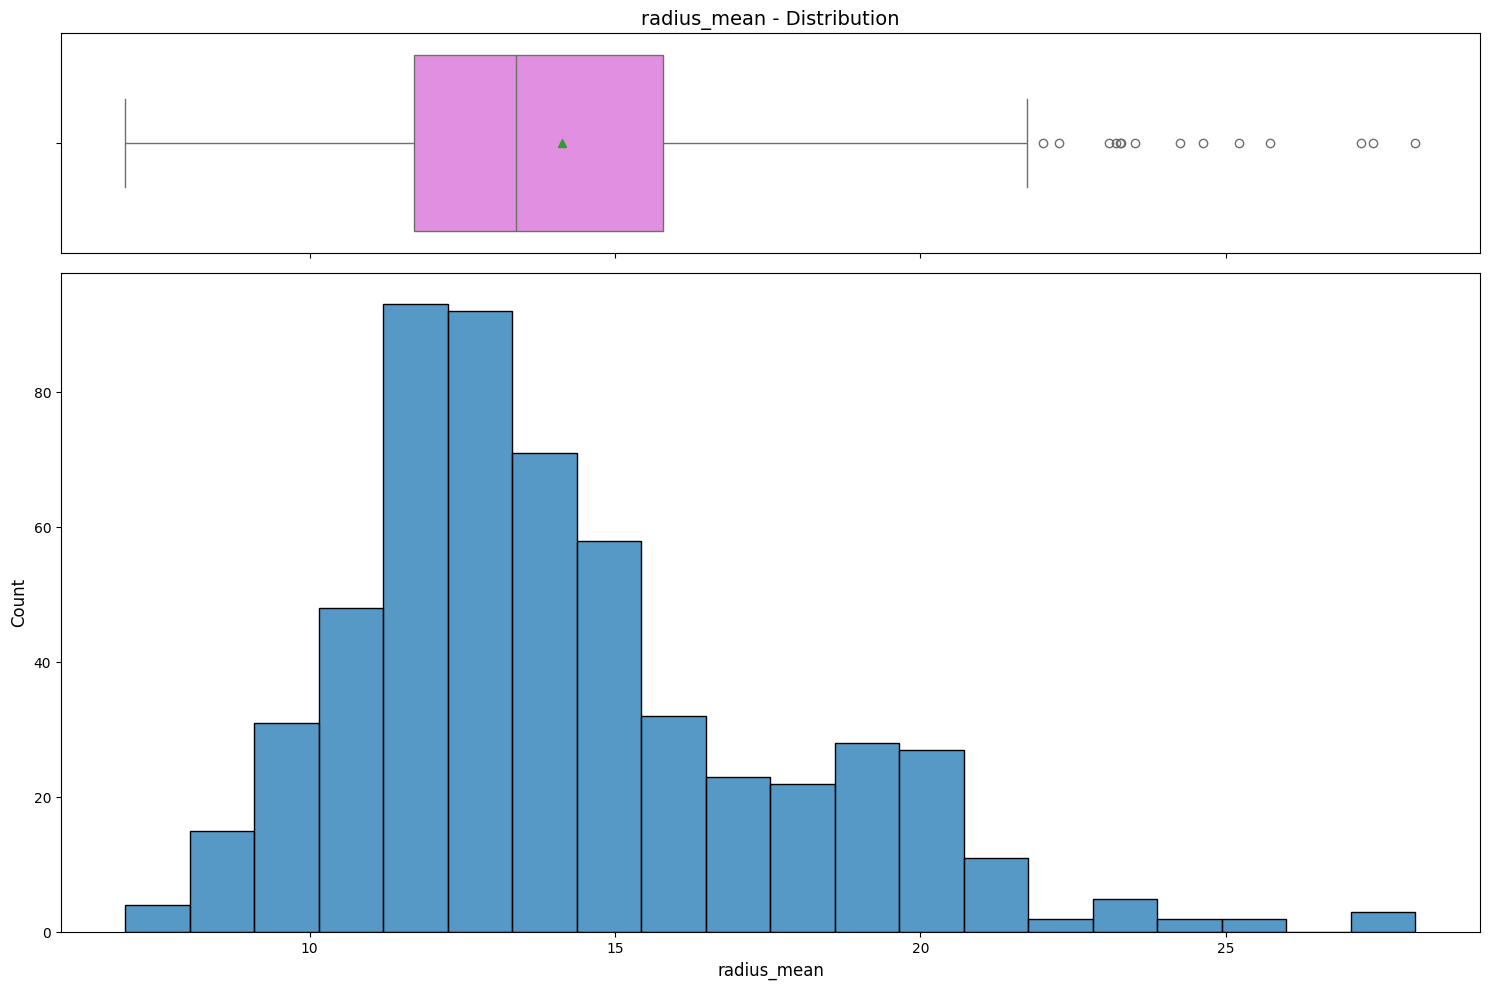

In [ ]:
histogram_boxplot(df1,"radius_mean")

## Observation on texture_mean

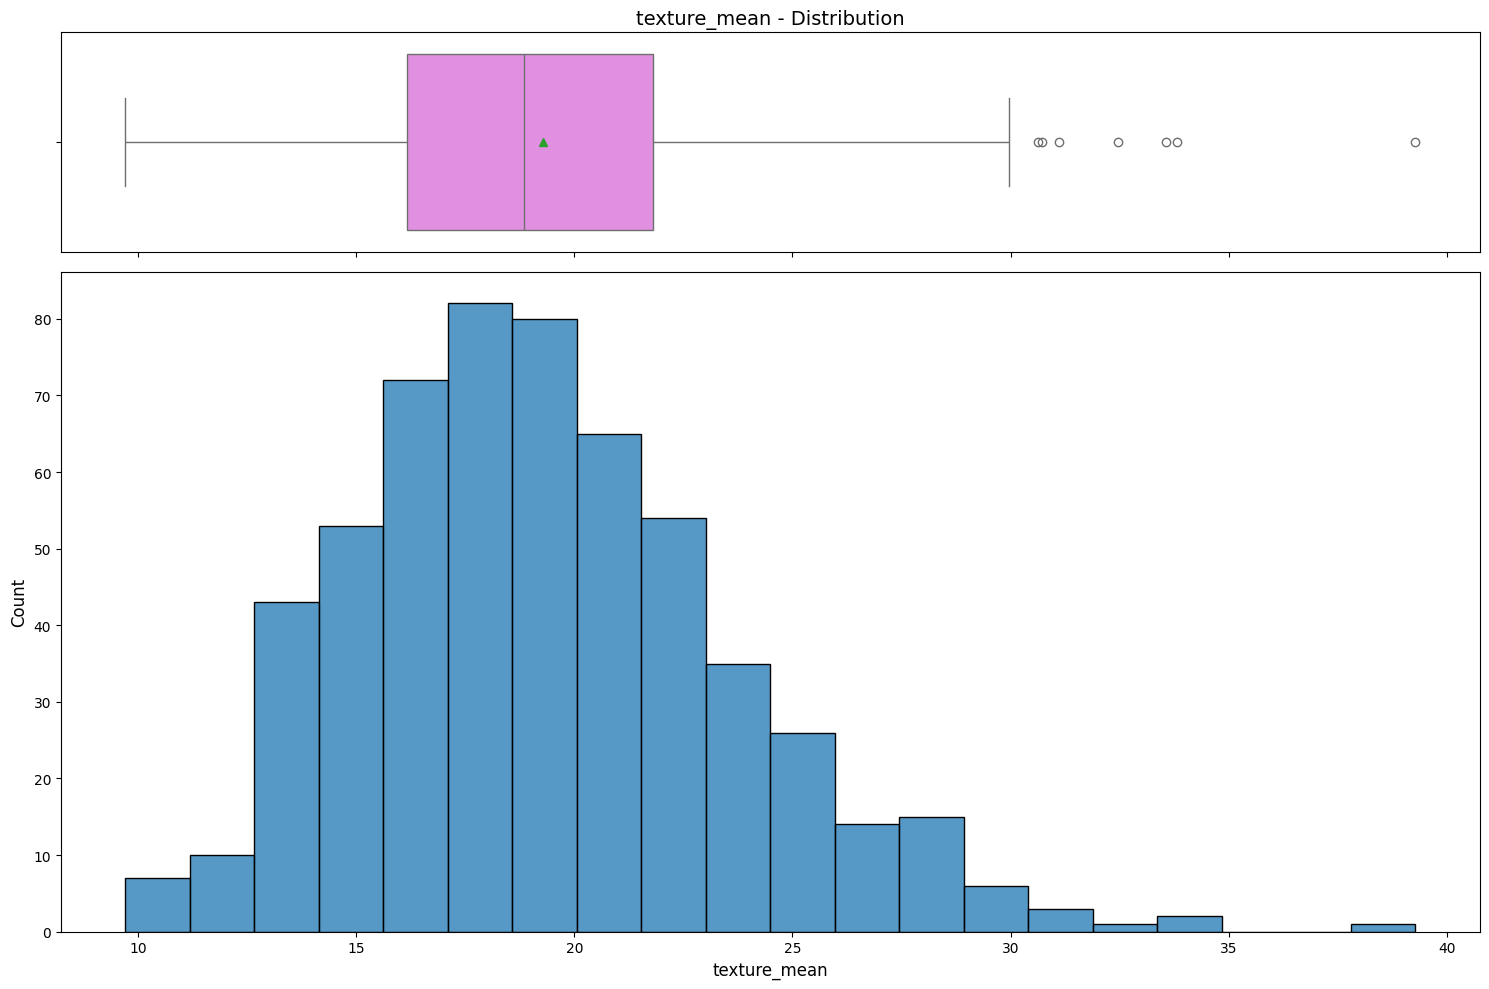

In [ ]:
histogram_boxplot(df1,"texture_mean")

## Observation on perimater_mean

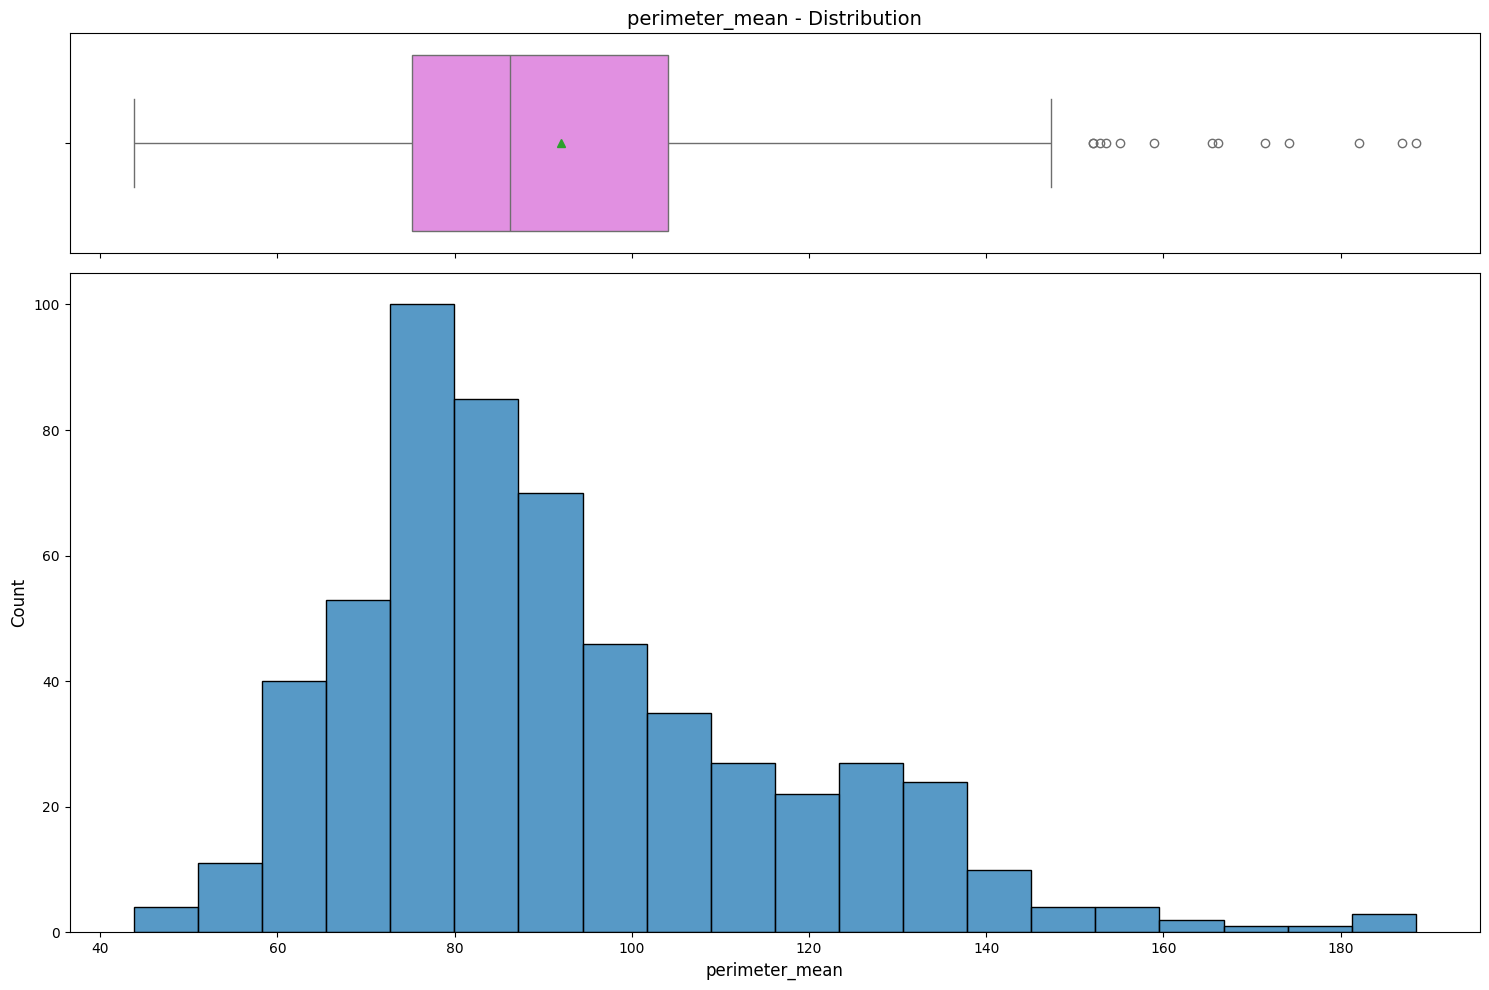

In [ ]:
histogram_boxplot(df1,"perimeter_mean")

## Observation on area_mean

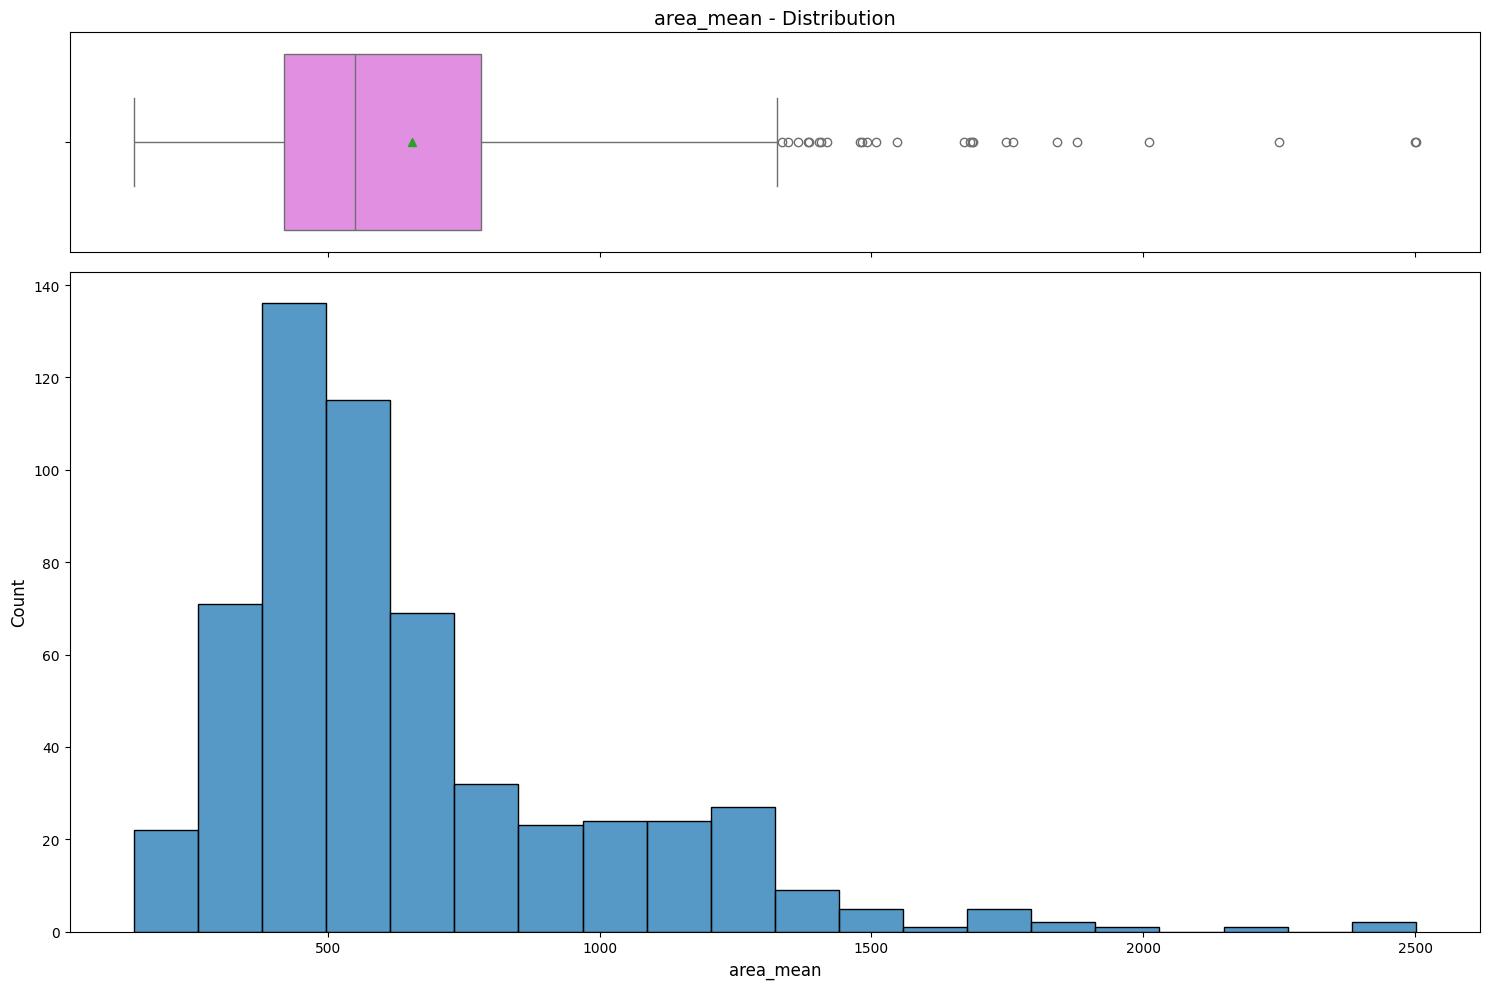

In [ ]:
histogram_boxplot(df1,"area_mean")

## Observation on smoothness_mean

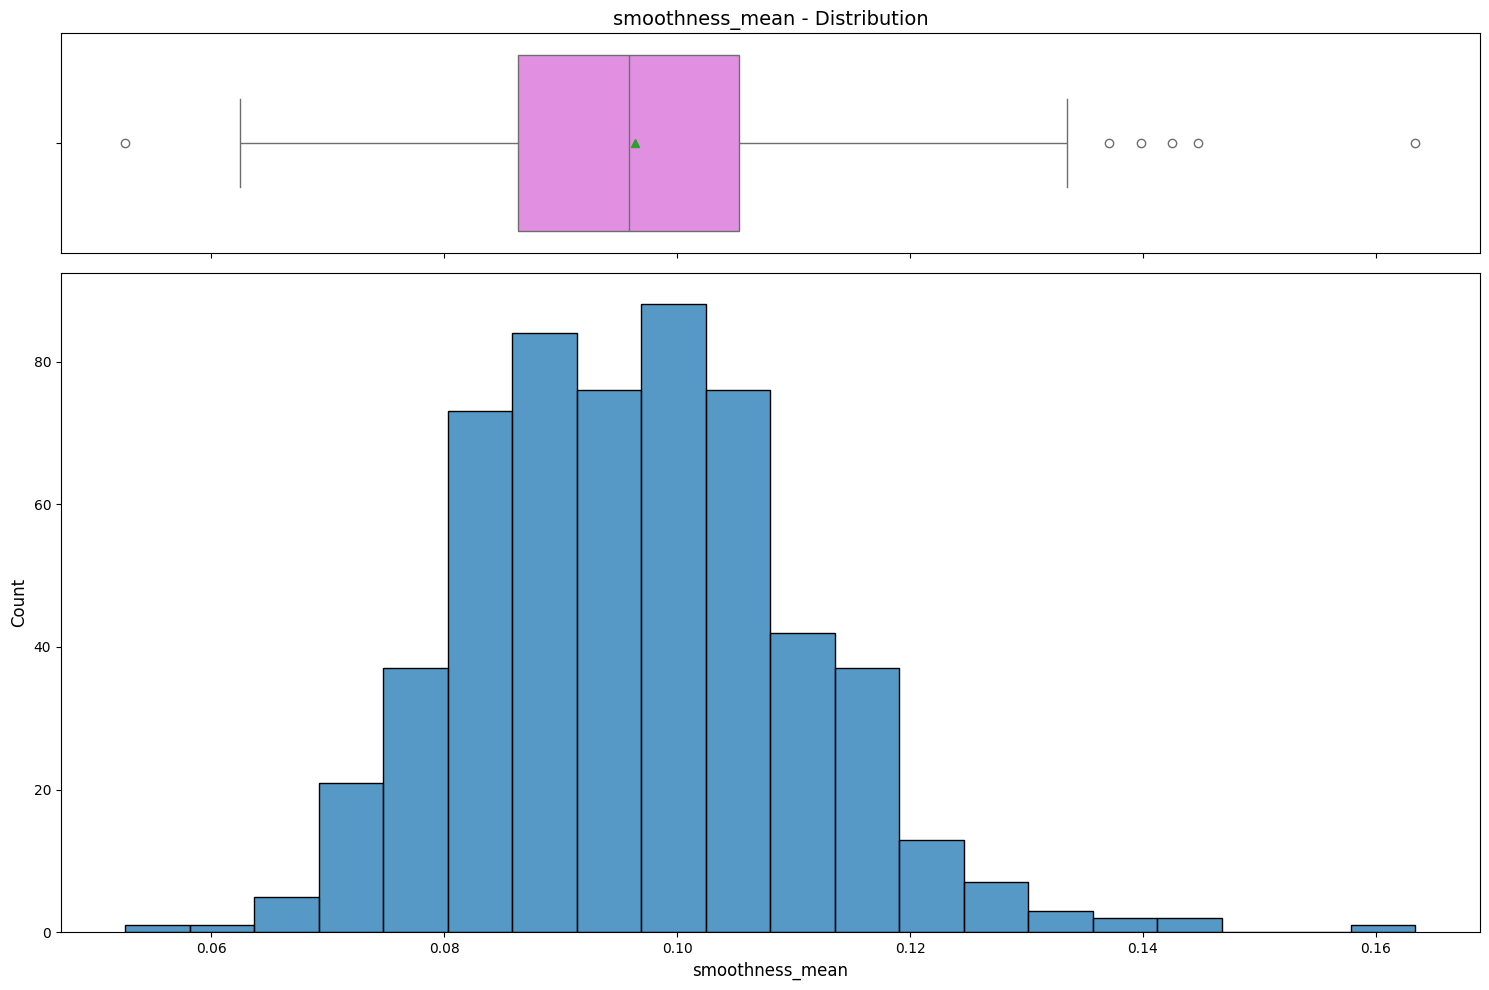

In [ ]:
histogram_boxplot(df1,"smoothness_mean")

## Observation on compactness_mean

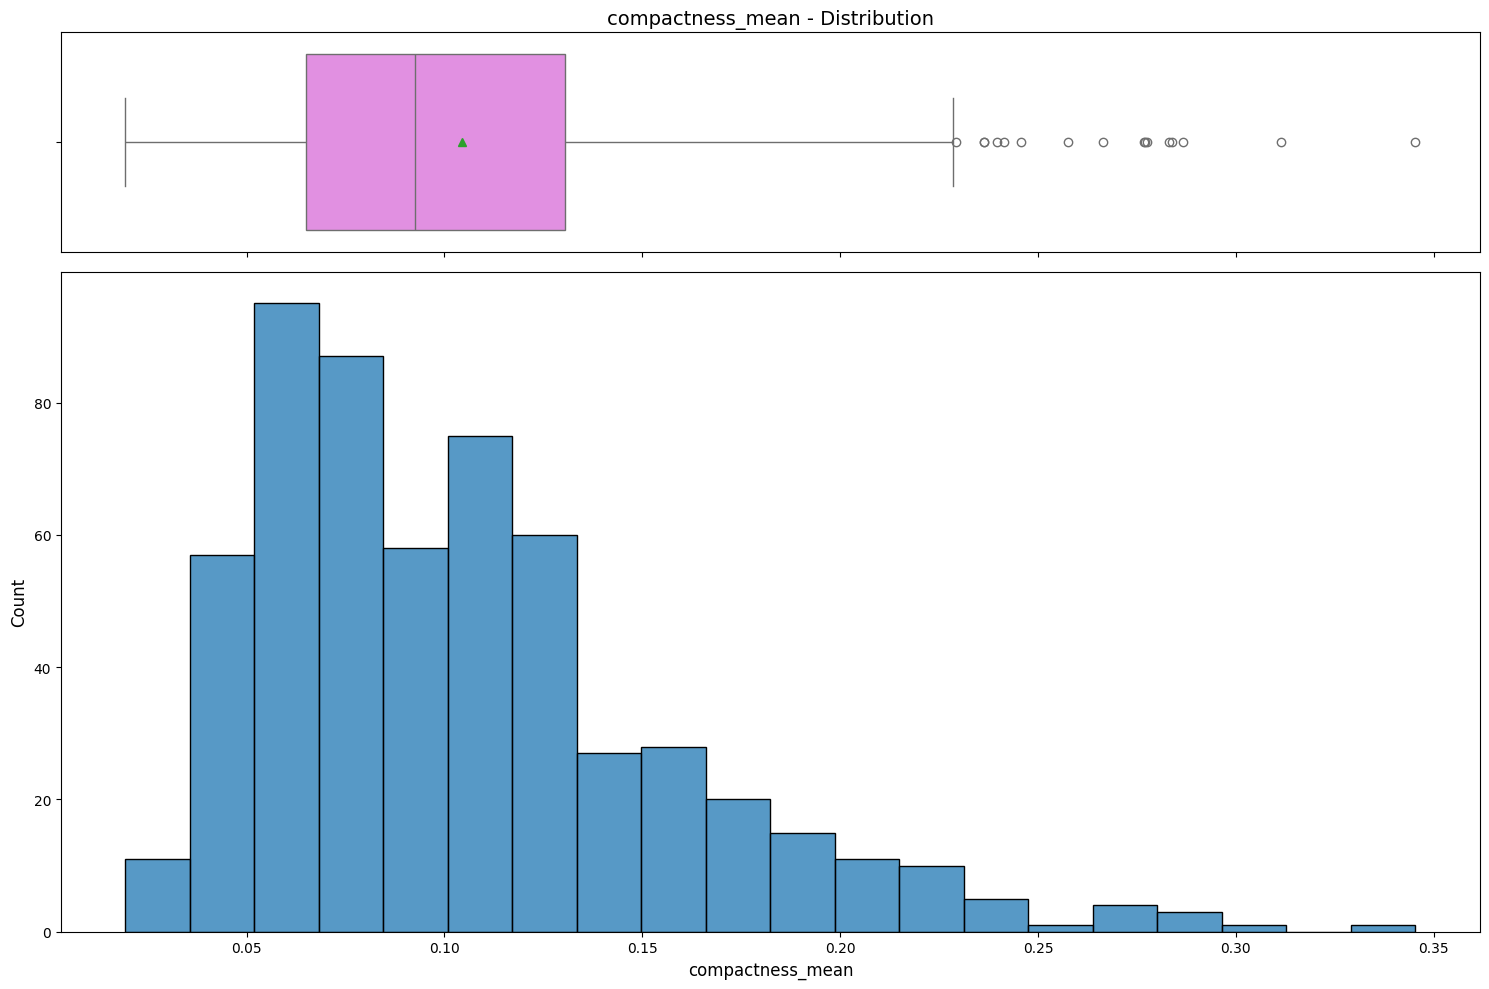

In [ ]:
histogram_boxplot(df1,"compactness_mean")

## Observation on concavity_mean

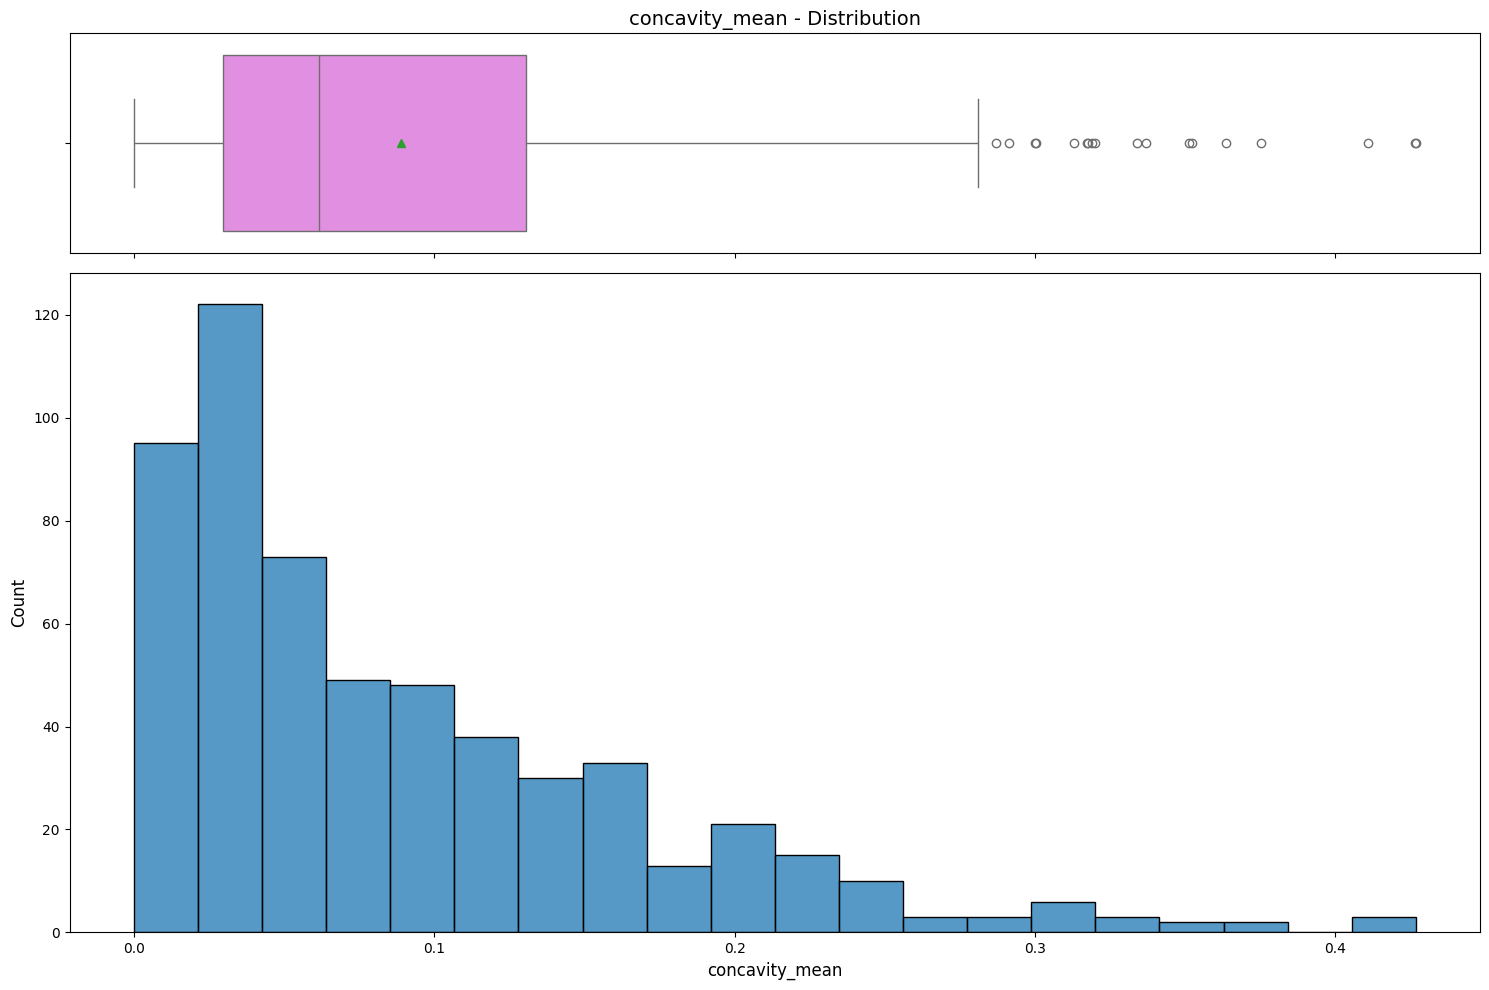

In [ ]:
histogram_boxplot(df1,"concavity_mean")

## Observation on concave points_mean

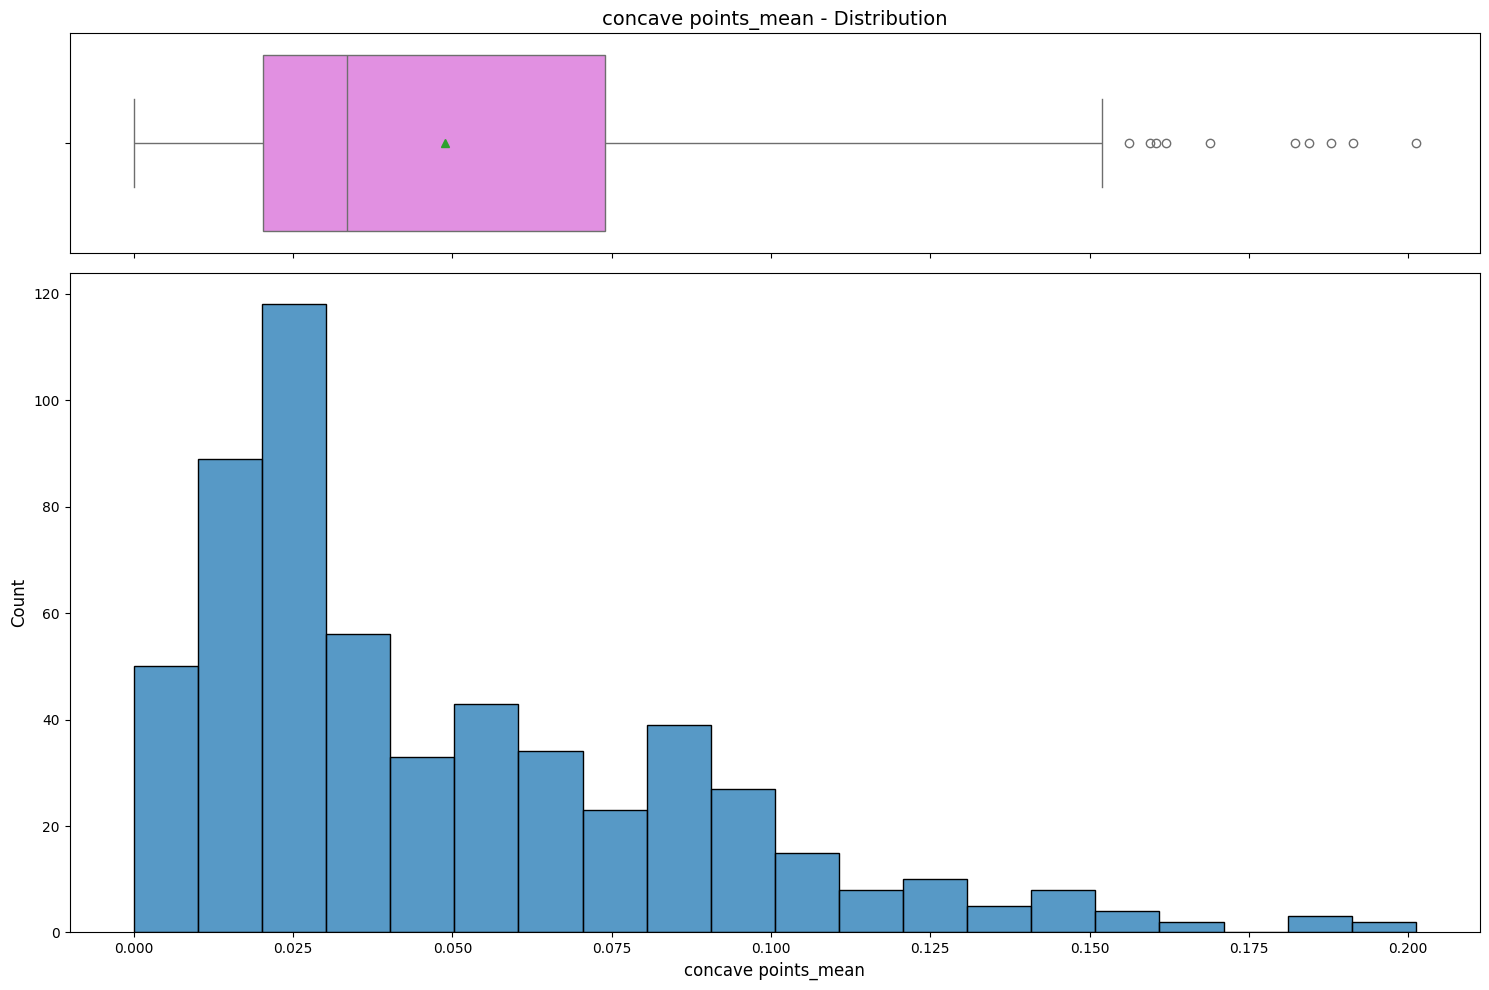

In [ ]:
histogram_boxplot(df1,"concave points_mean")

## Observation on symmetry_mean

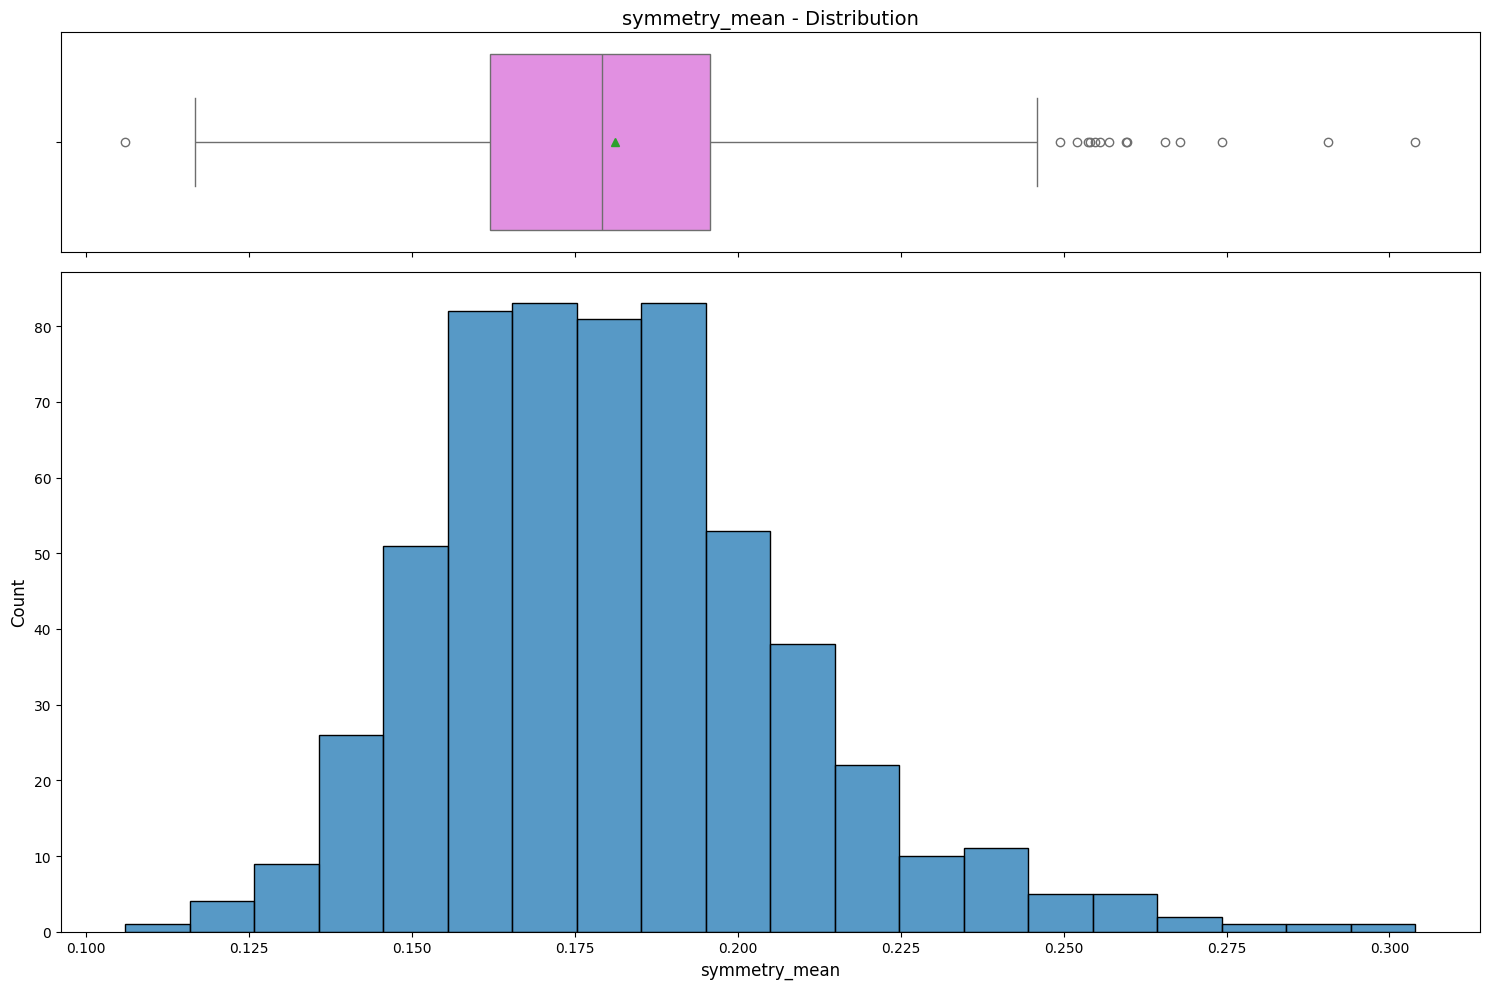

In [ ]:
histogram_boxplot(df1,"symmetry_mean")

## Observation on fractal_dimension_mean

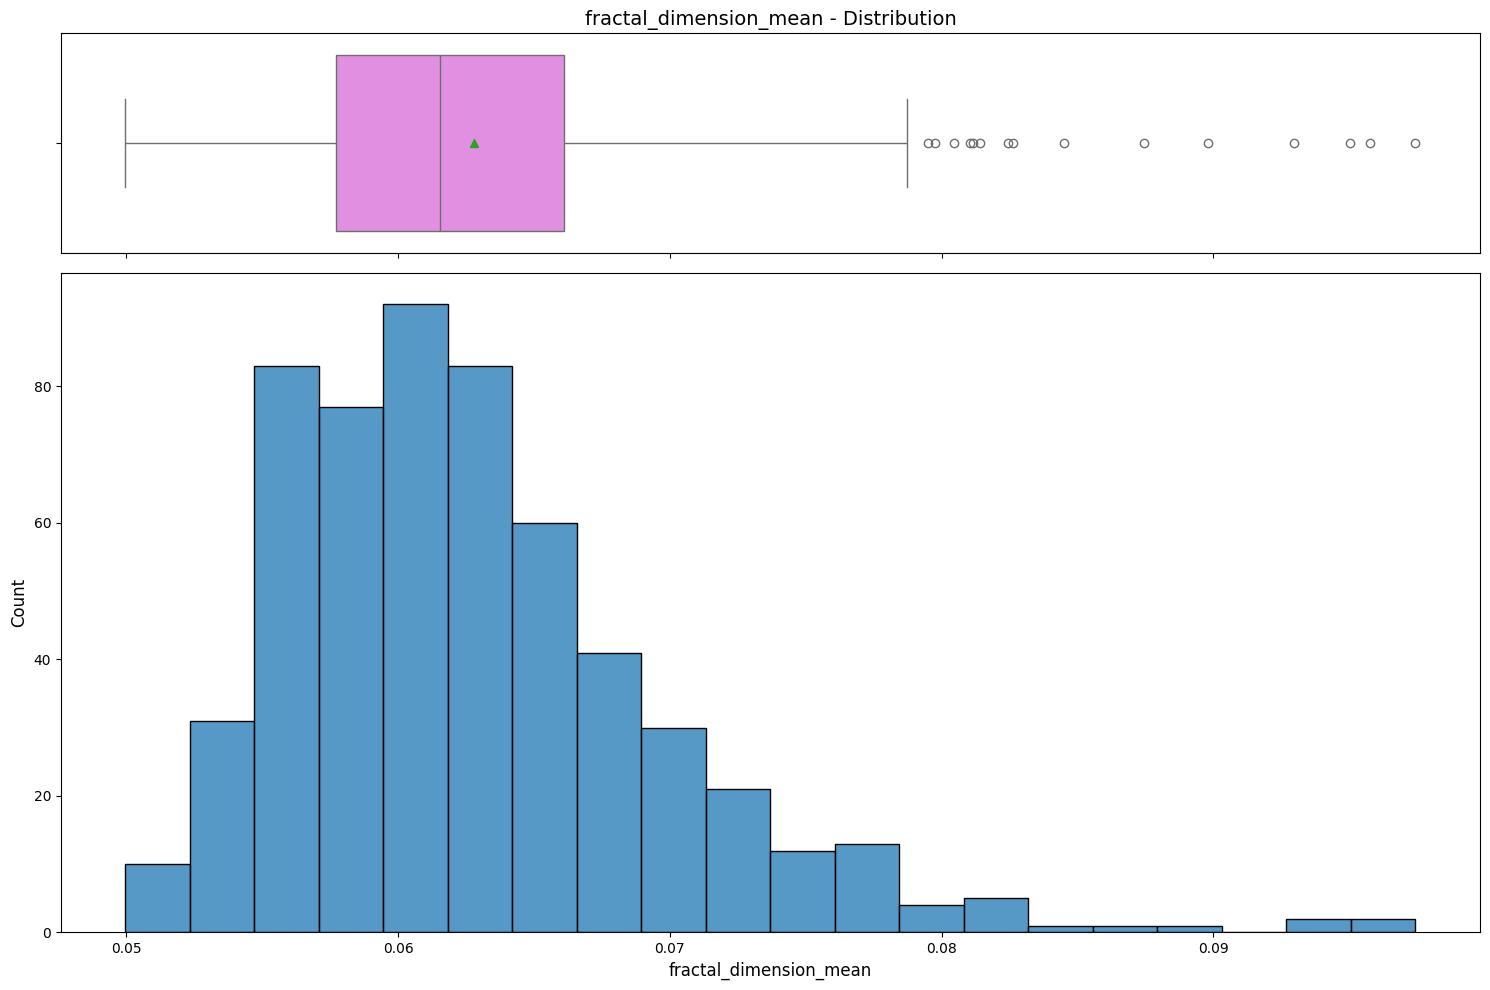

In [ ]:
histogram_boxplot(df1,"fractal_dimension_mean")

## Observation on radius_se

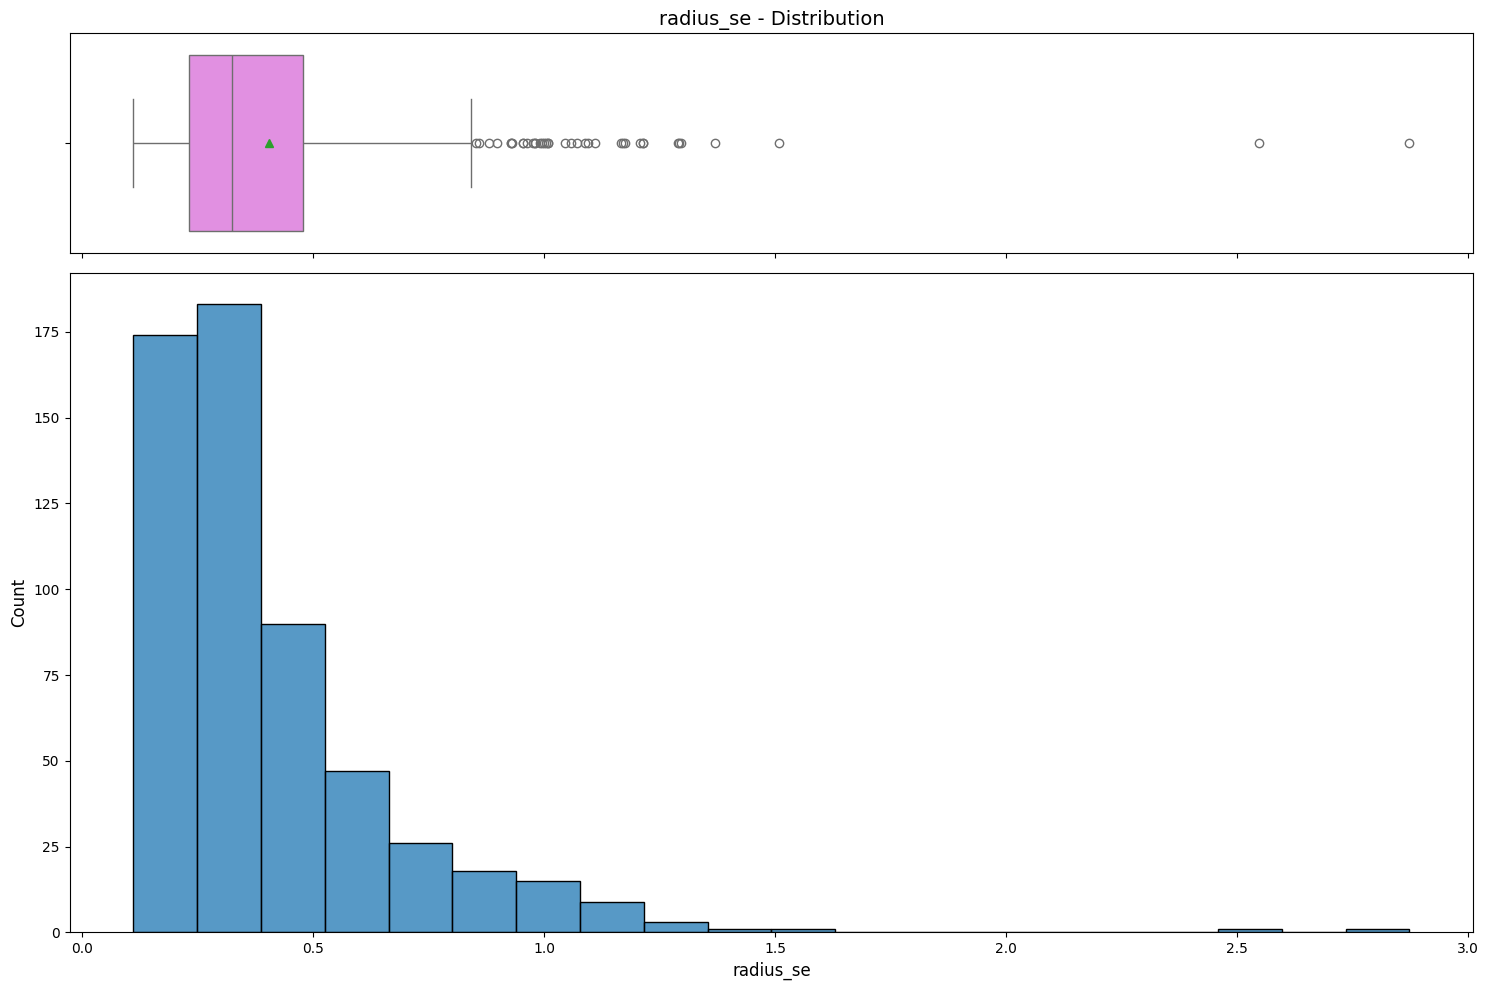

In [ ]:
histogram_boxplot(df1,"radius_se")

## Observation on texture_se

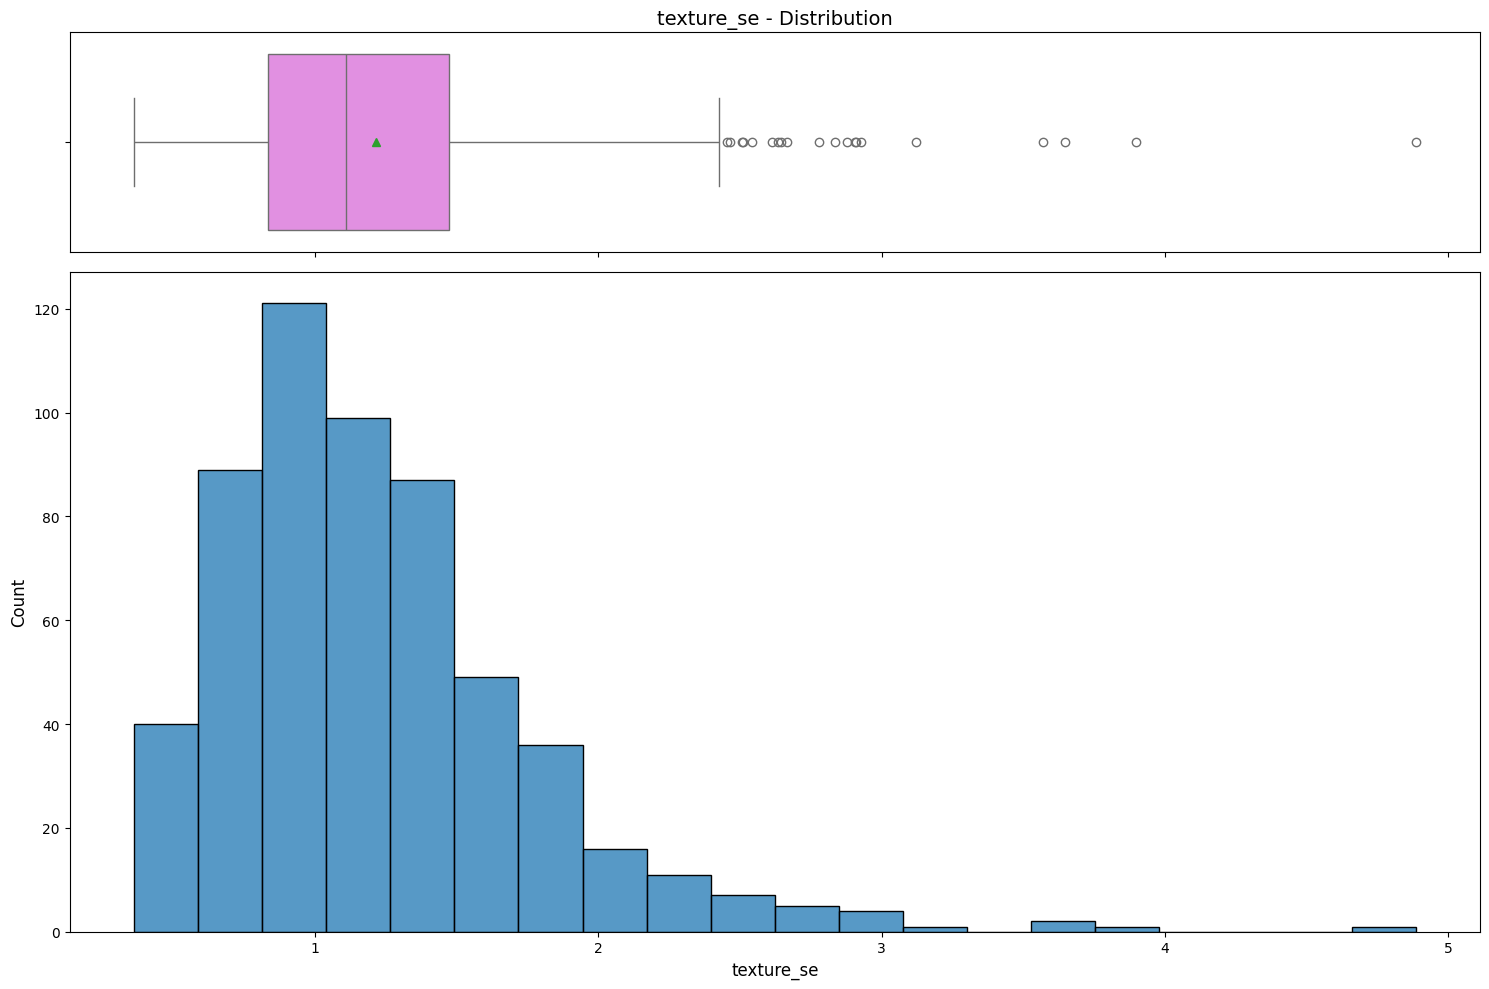

In [ ]:
histogram_boxplot(df1,"texture_se")

## Observation on perimeter_se

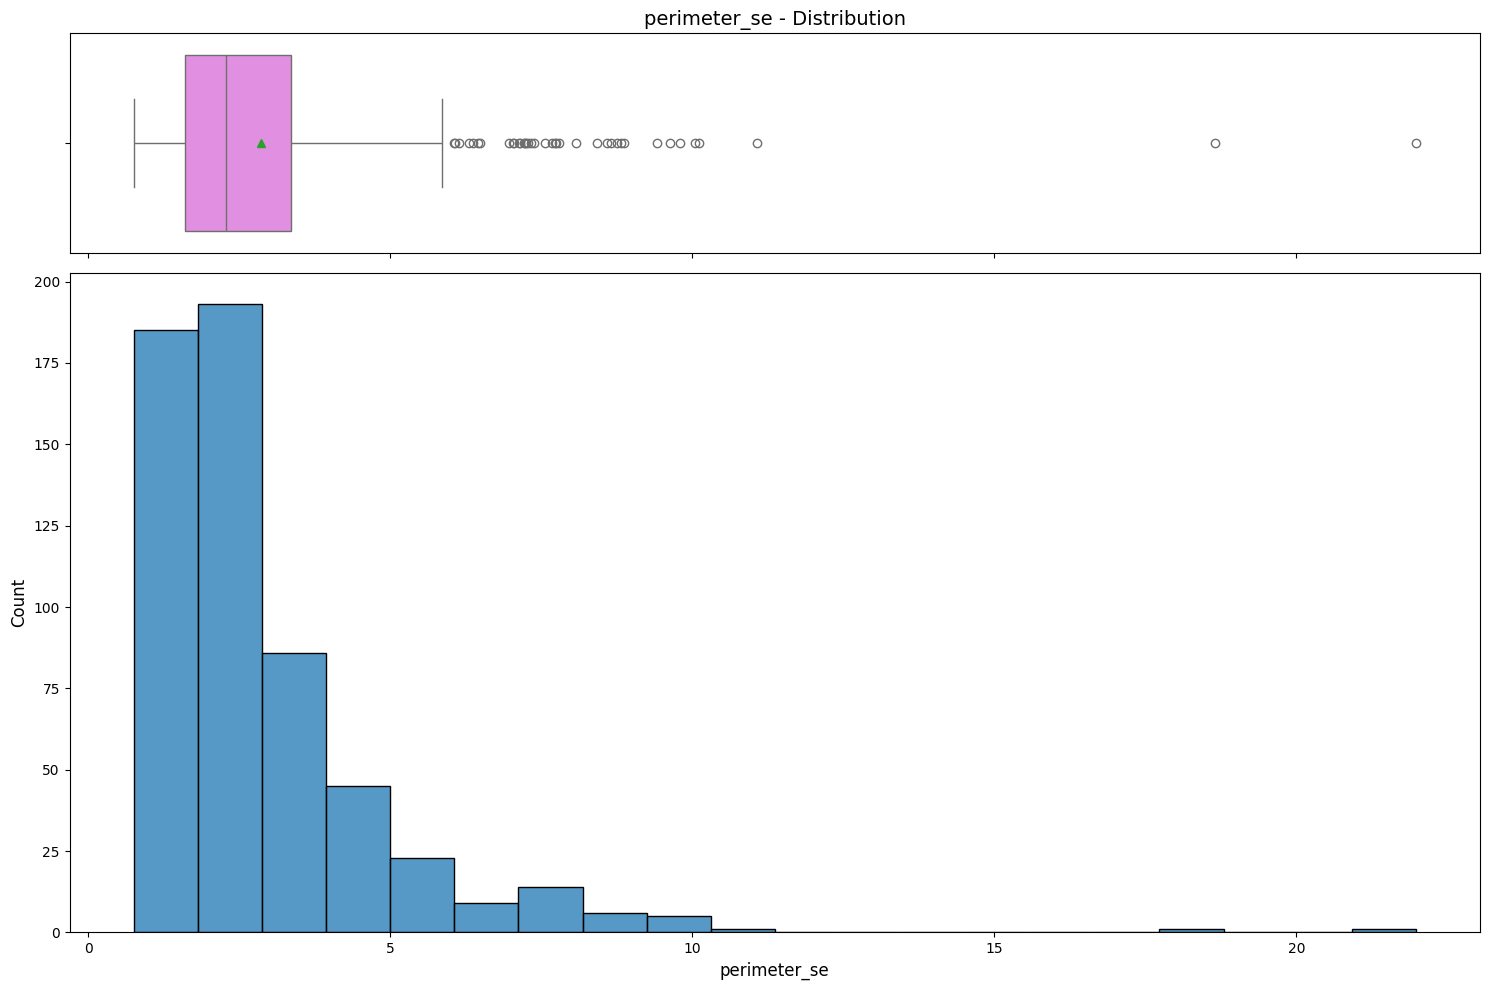

In [ ]:
histogram_boxplot(df1,"perimeter_se")

## Observation on area_se

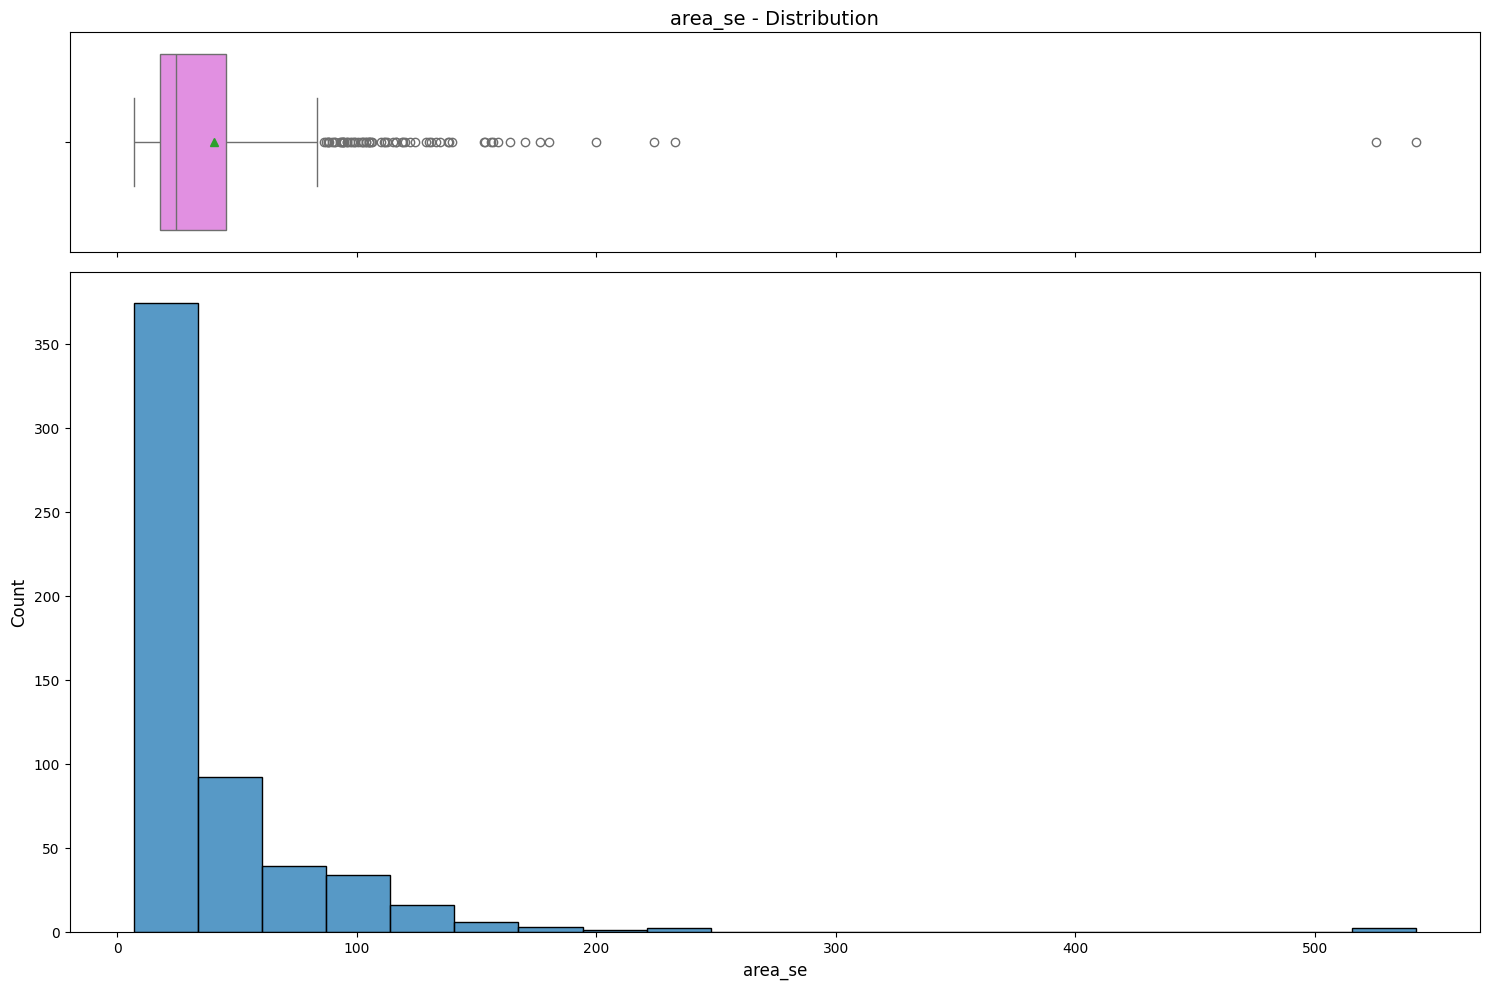

In [ ]:
histogram_boxplot(df1,"area_se")

## Observation on smoothness_se

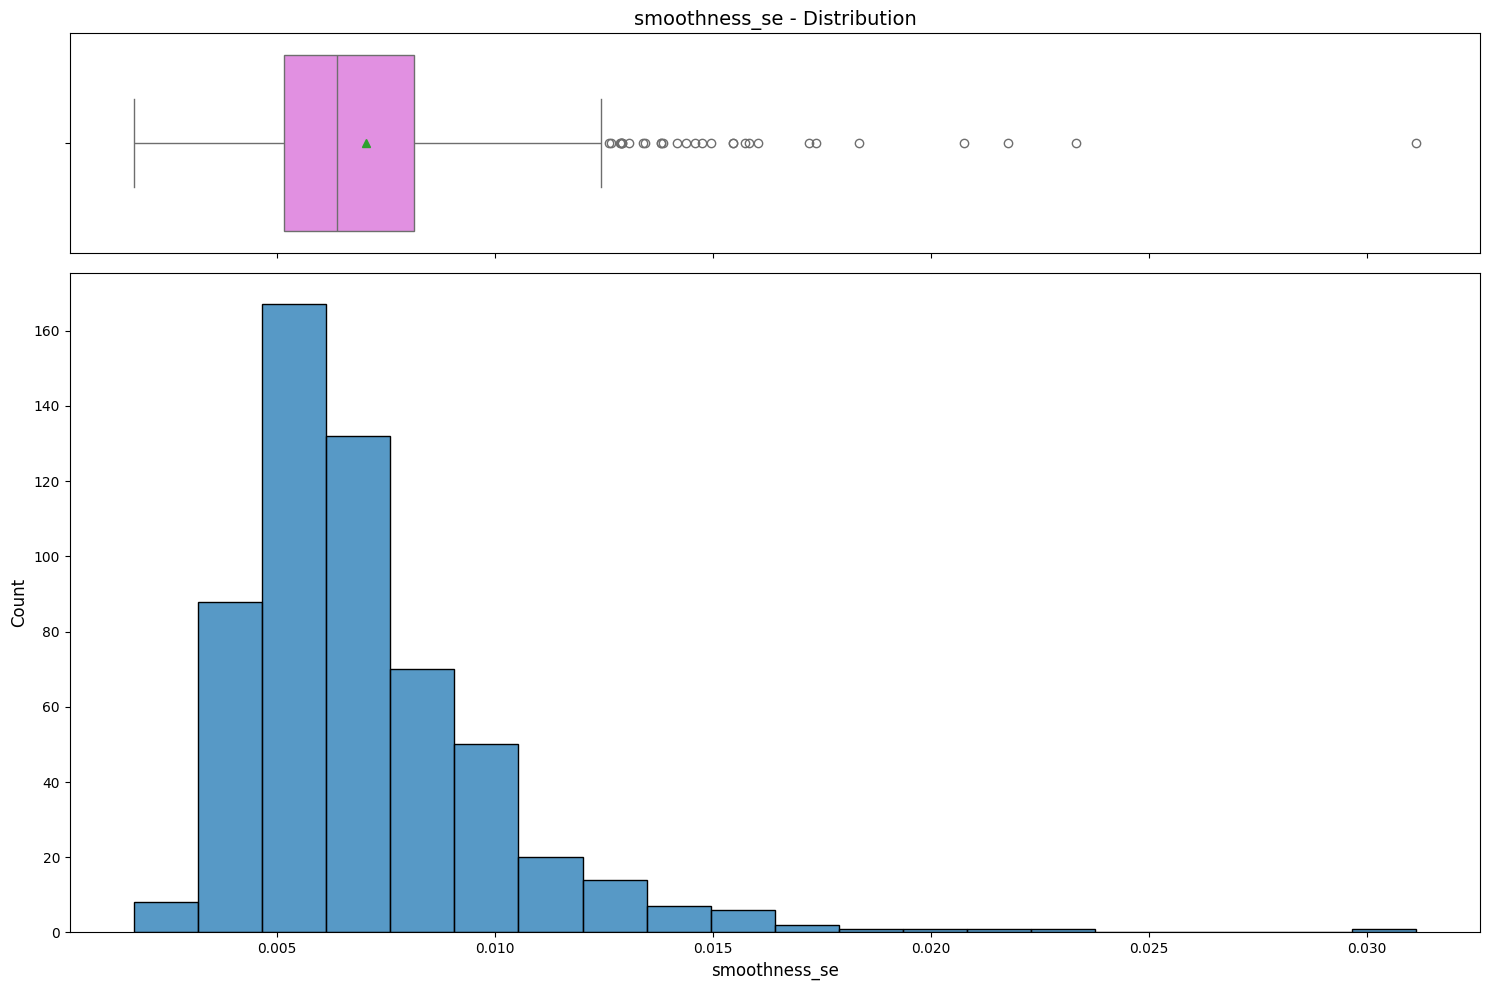

In [ ]:
histogram_boxplot(df1,"smoothness_se")

## Observation on compactness_se

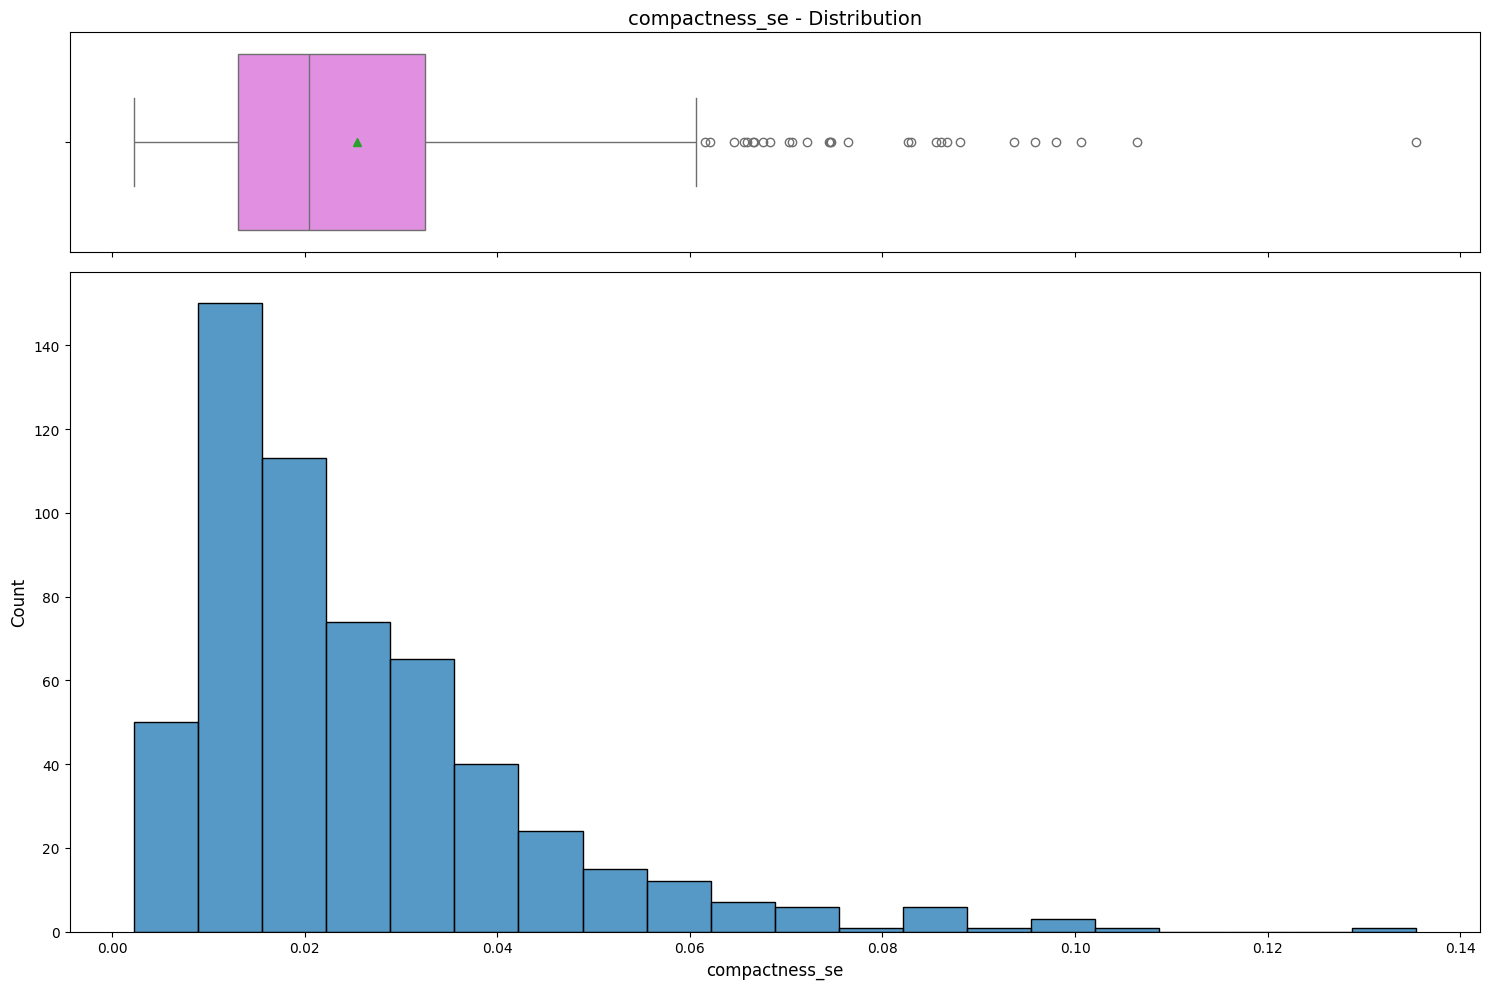

In [ ]:
histogram_boxplot(df1,"compactness_se")

## Observation on concavity_se

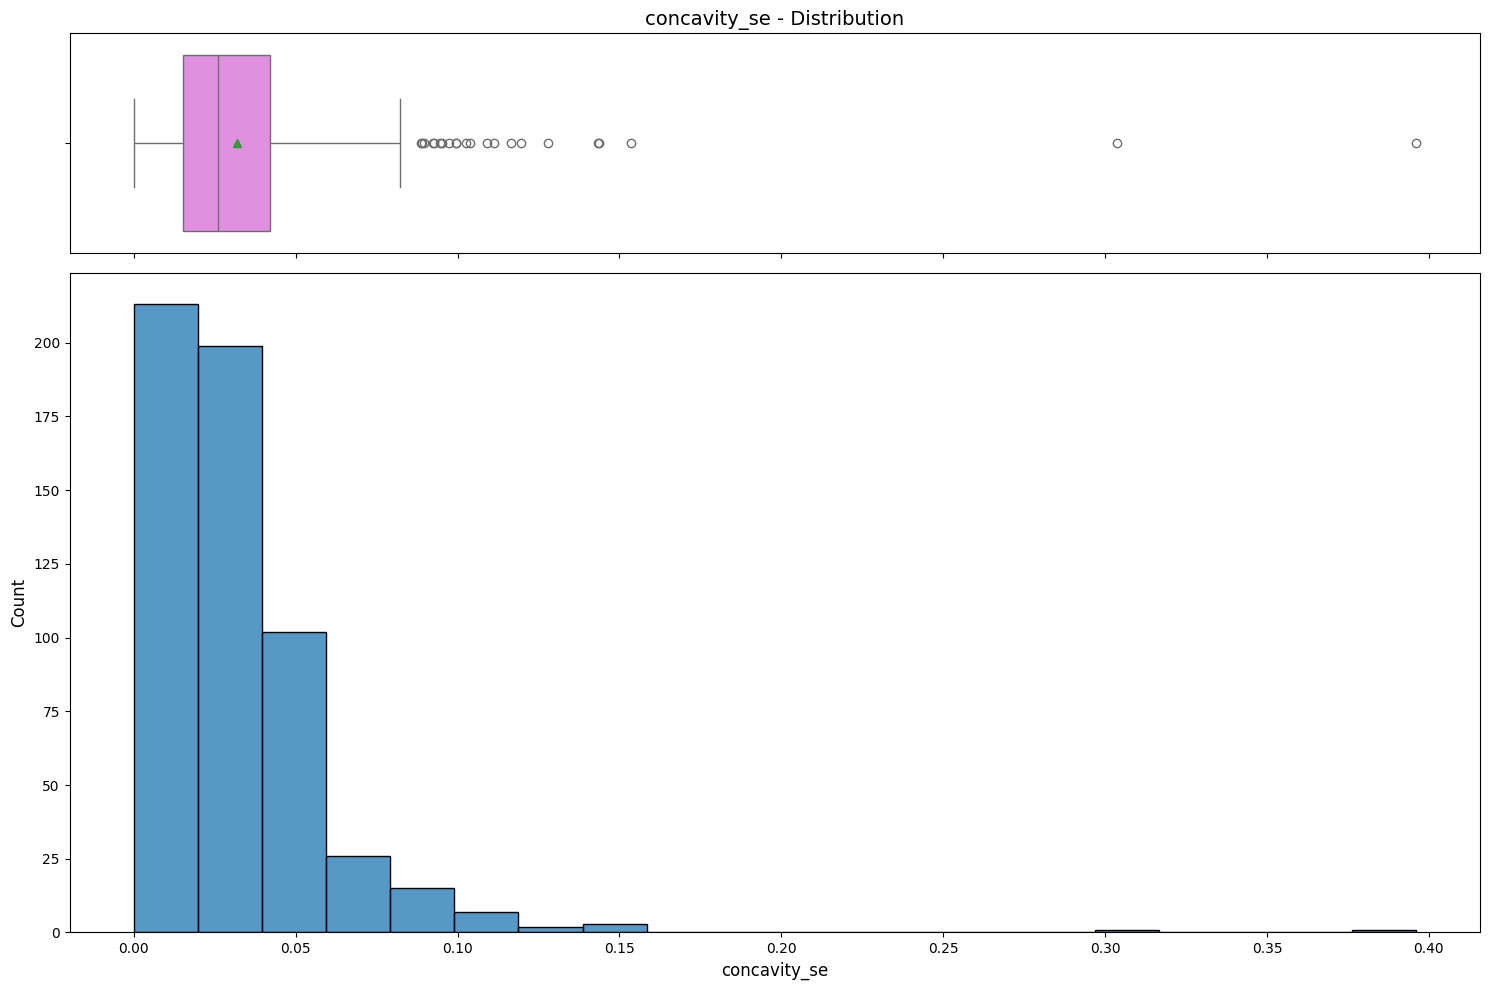

In [ ]:
histogram_boxplot(df1,"concavity_se")

## Observation on concave points_se

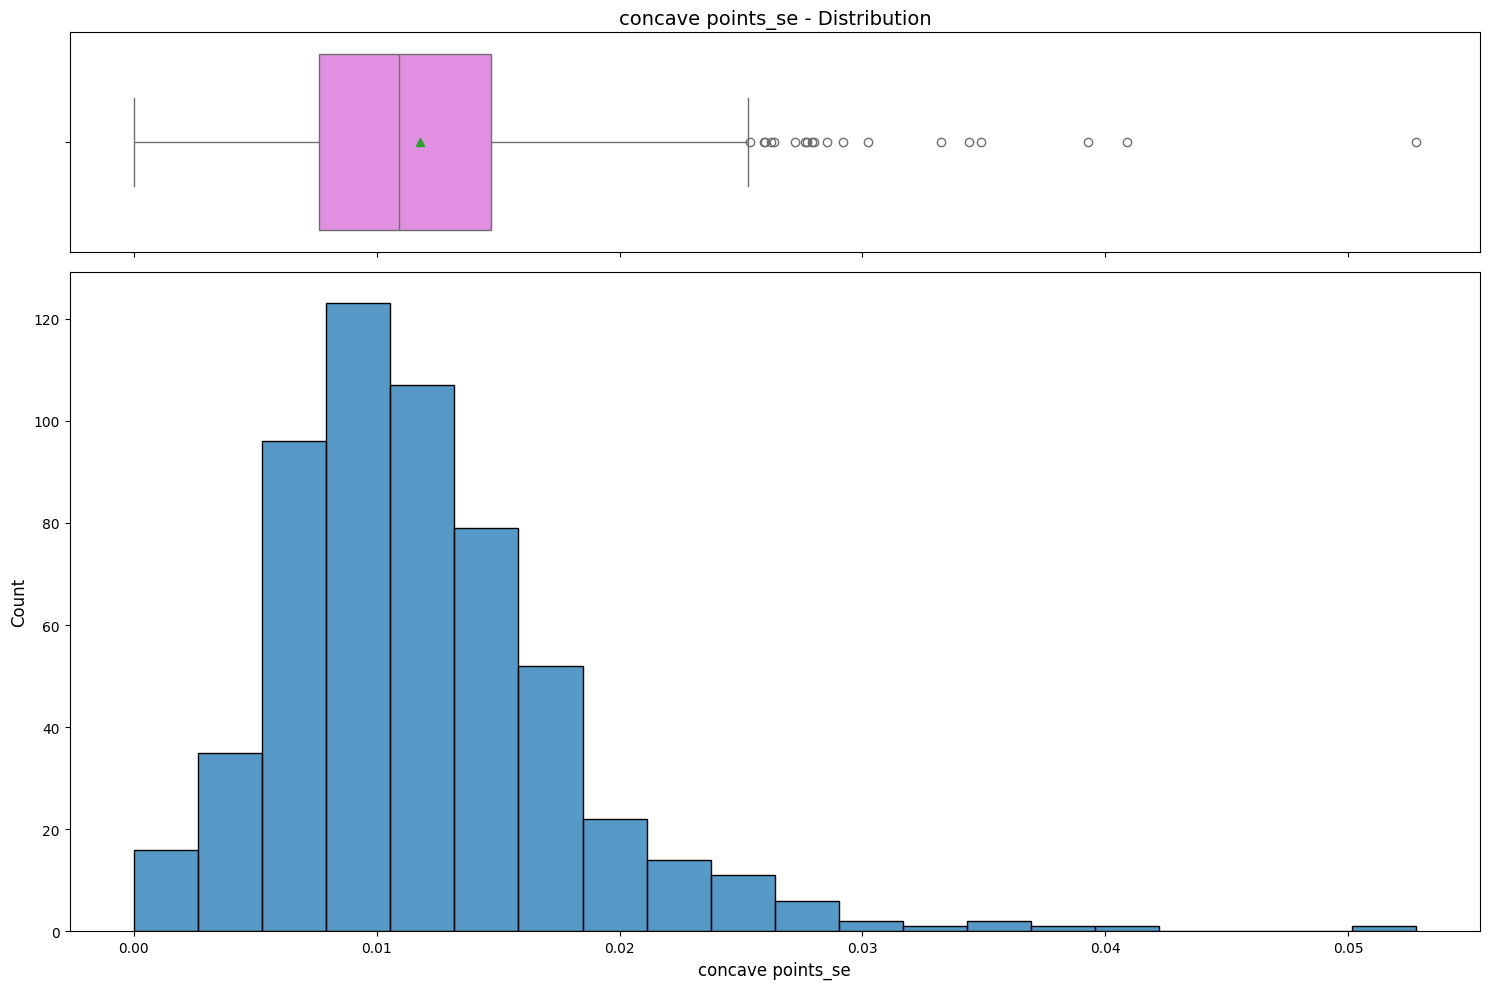

In [ ]:
histogram_boxplot(df1,"concave points_se")

## Observation on symmetry_se

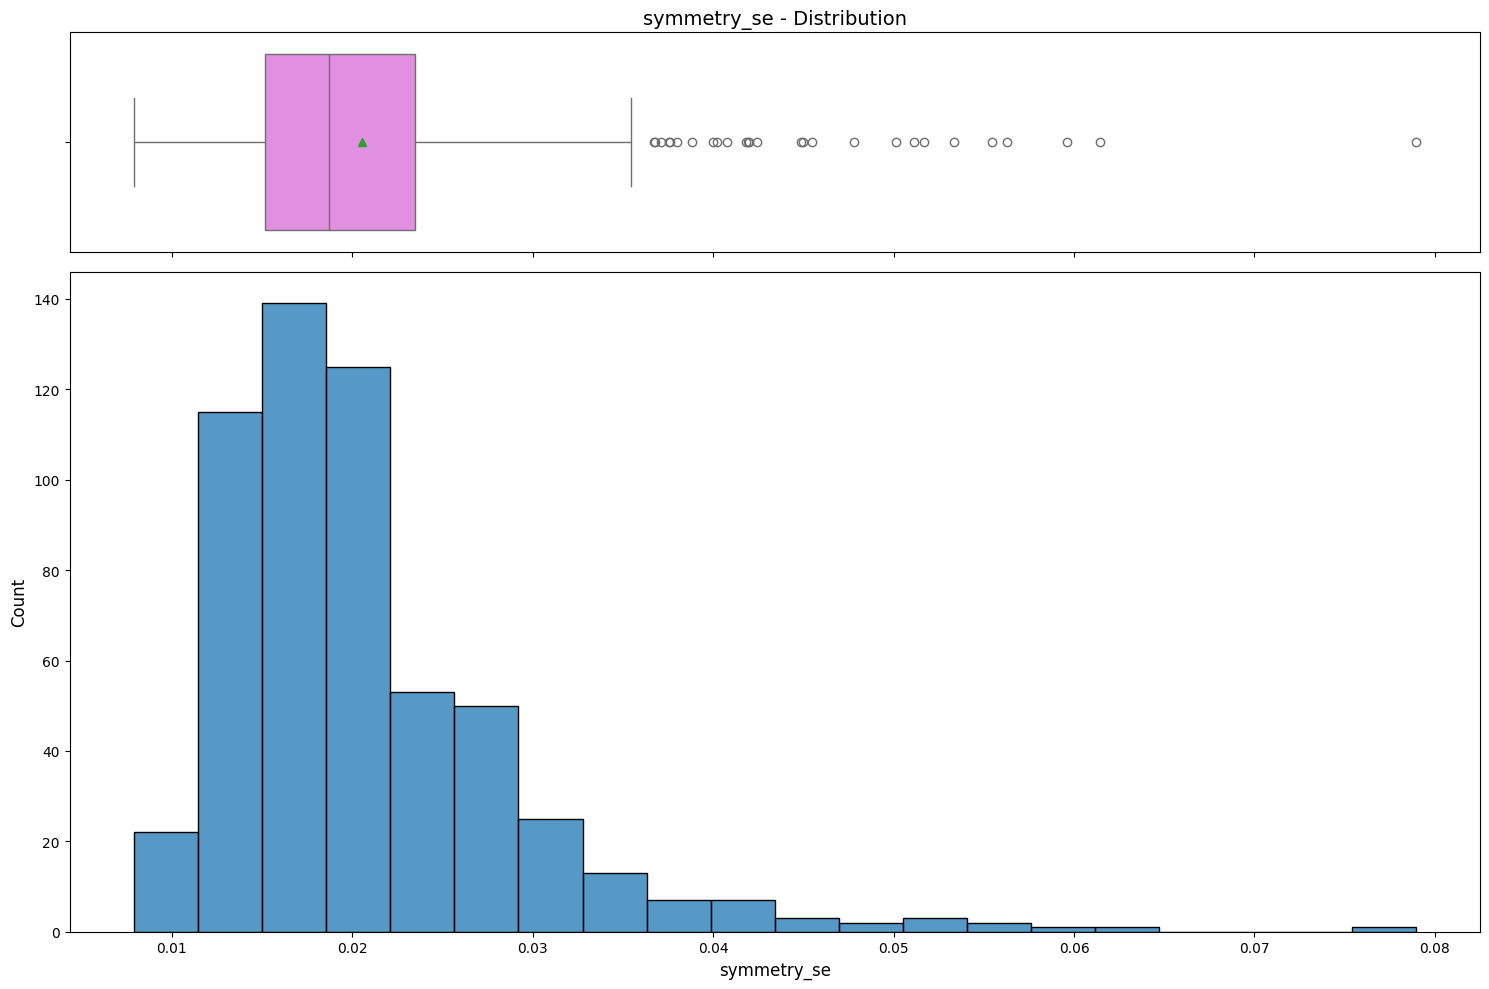

In [ ]:
histogram_boxplot(df1,"symmetry_se")

## Observation on fractal_dimension_se

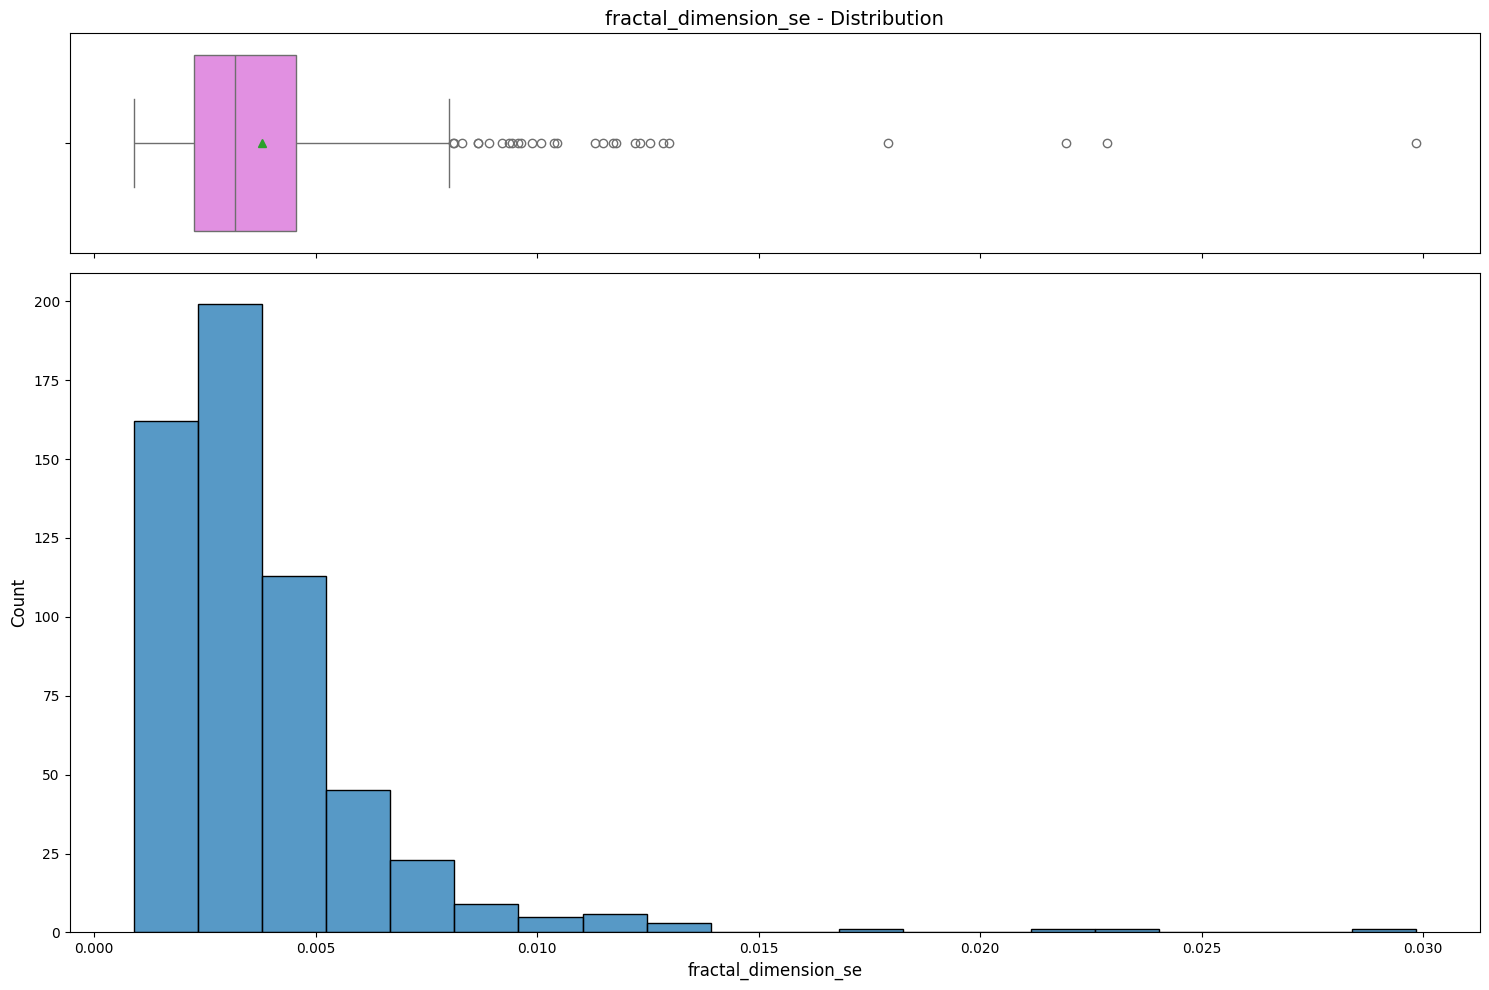

In [ ]:
histogram_boxplot(df1,"fractal_dimension_se")

## Observation on radius_worst

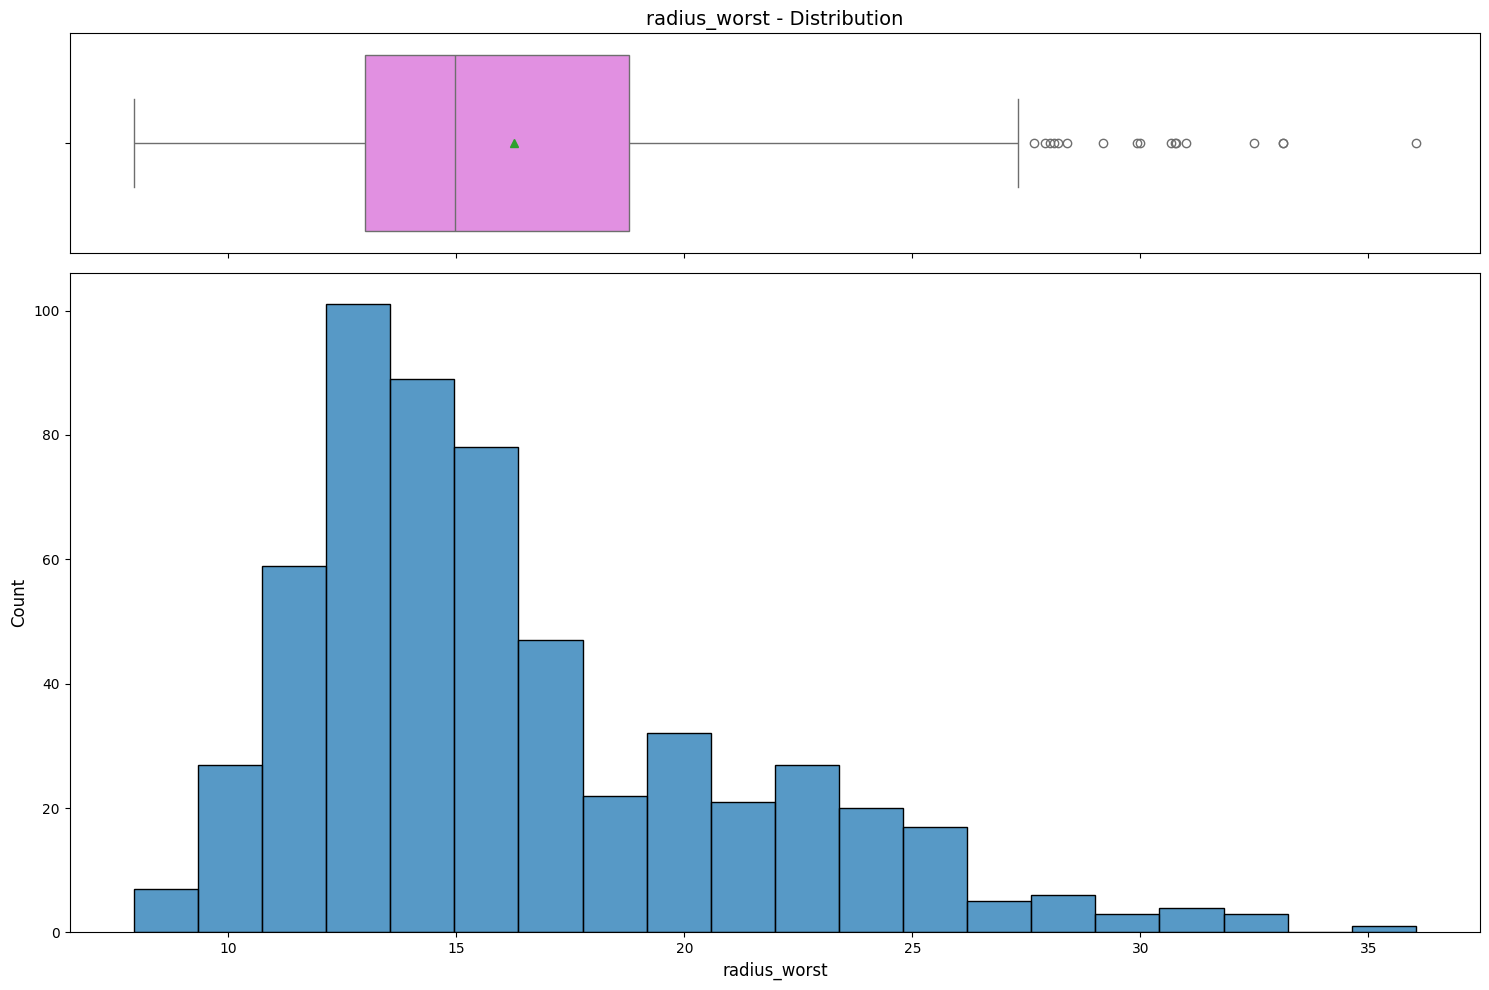

In [ ]:
histogram_boxplot(df1,"radius_worst")

## Observation on texture_worst

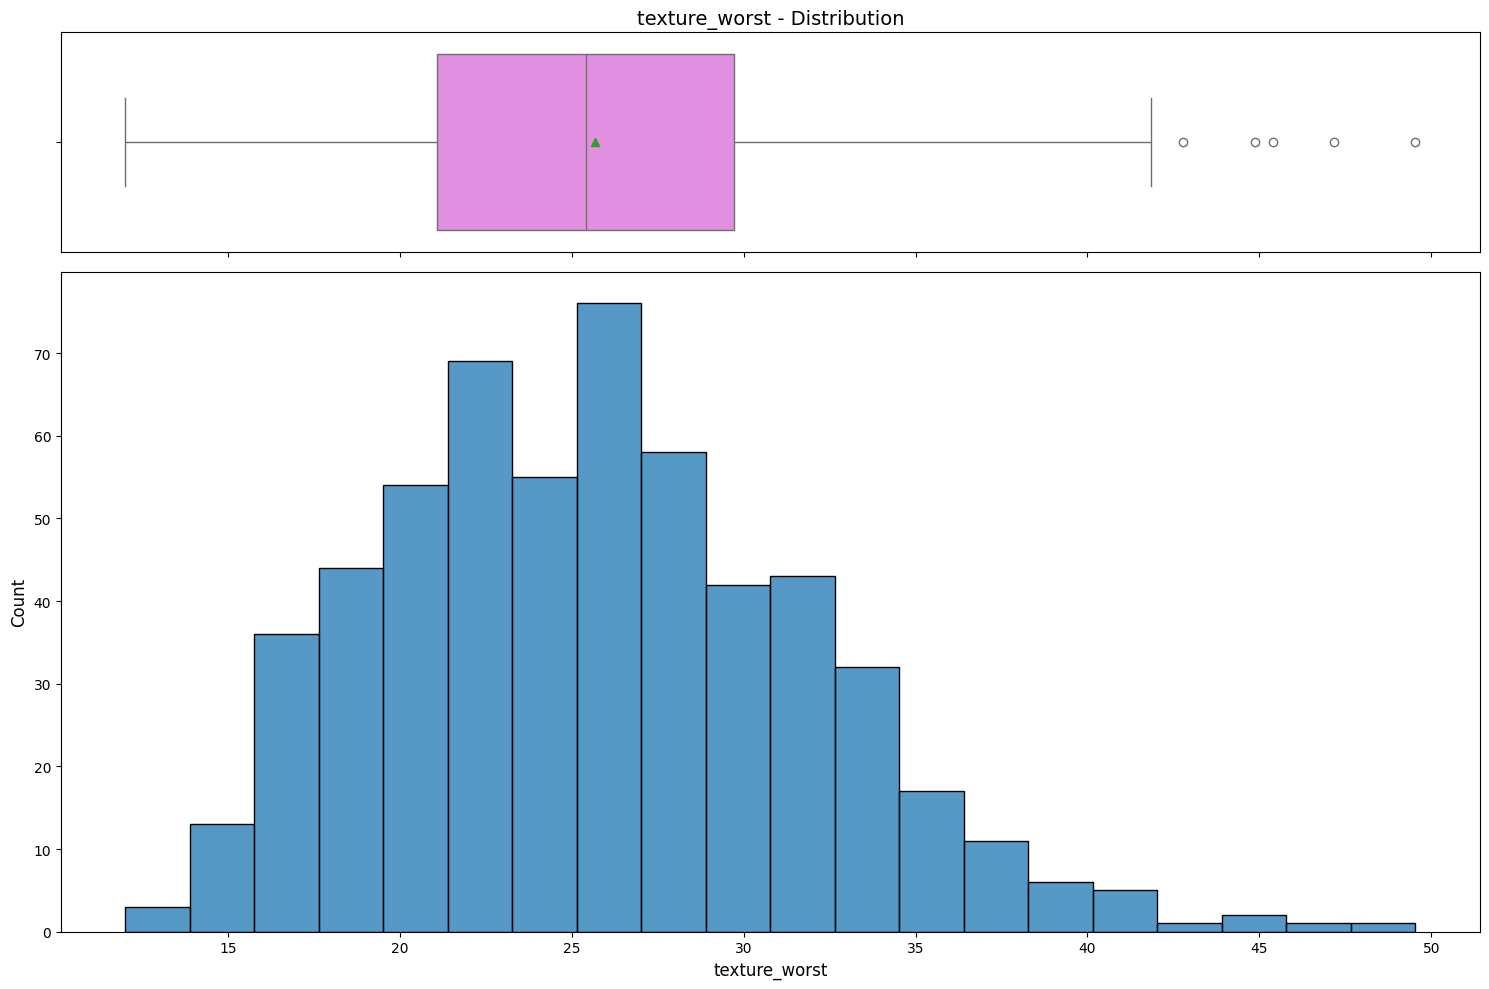

In [ ]:
histogram_boxplot(df1,"texture_worst")

## Observation on perimeter_worst

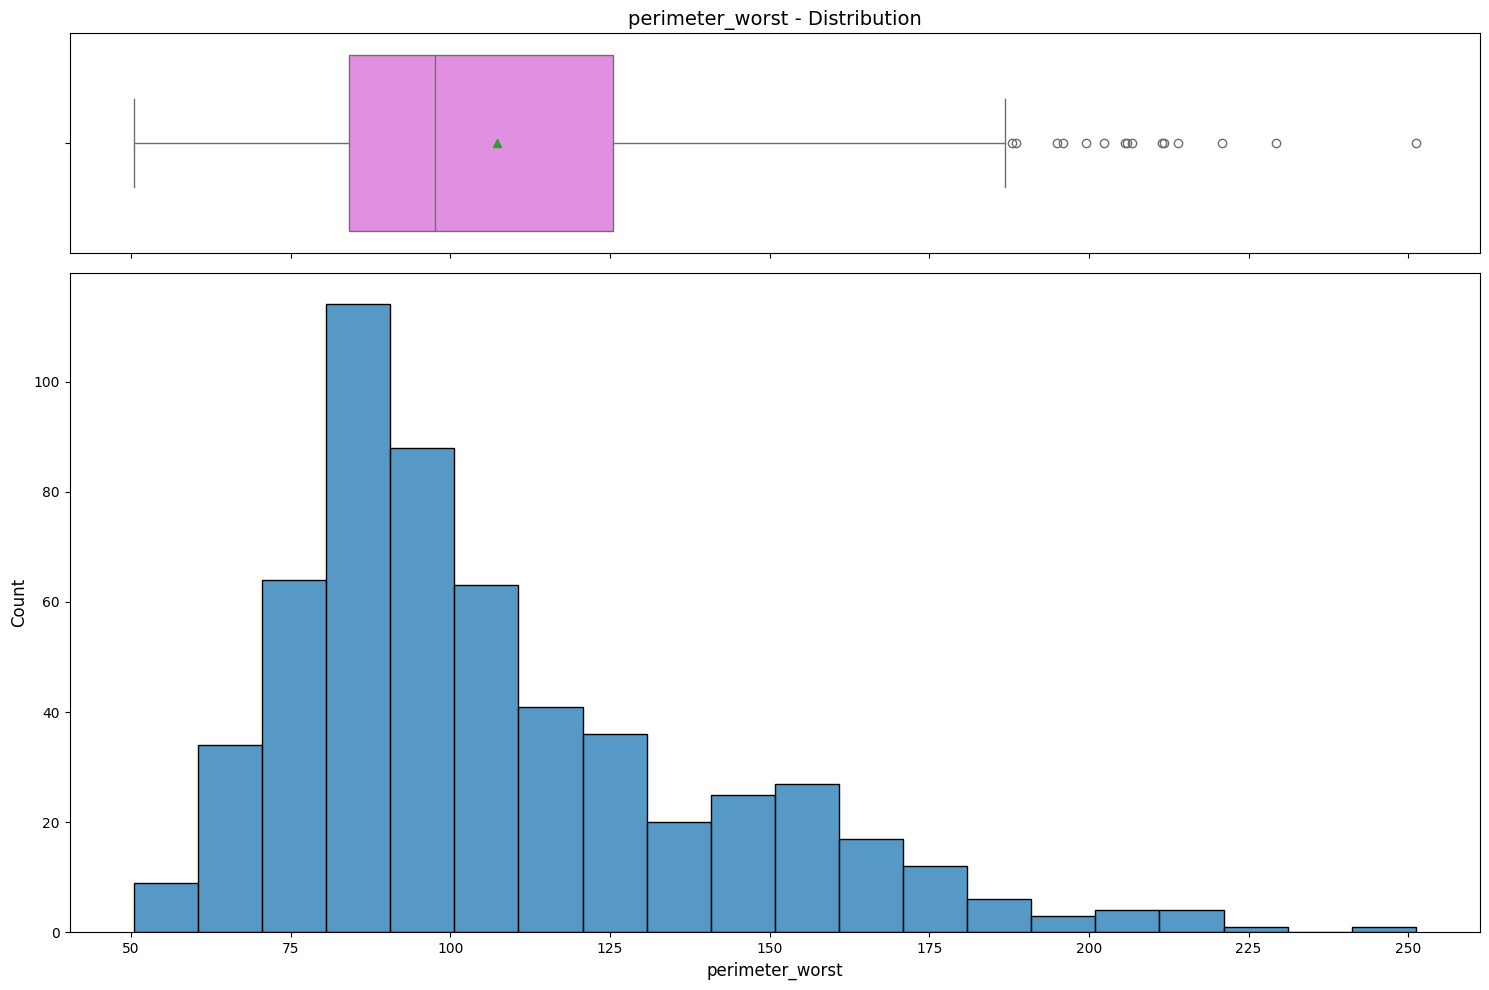

In [ ]:
histogram_boxplot(df1,"perimeter_worst")

## Observation on area_worst

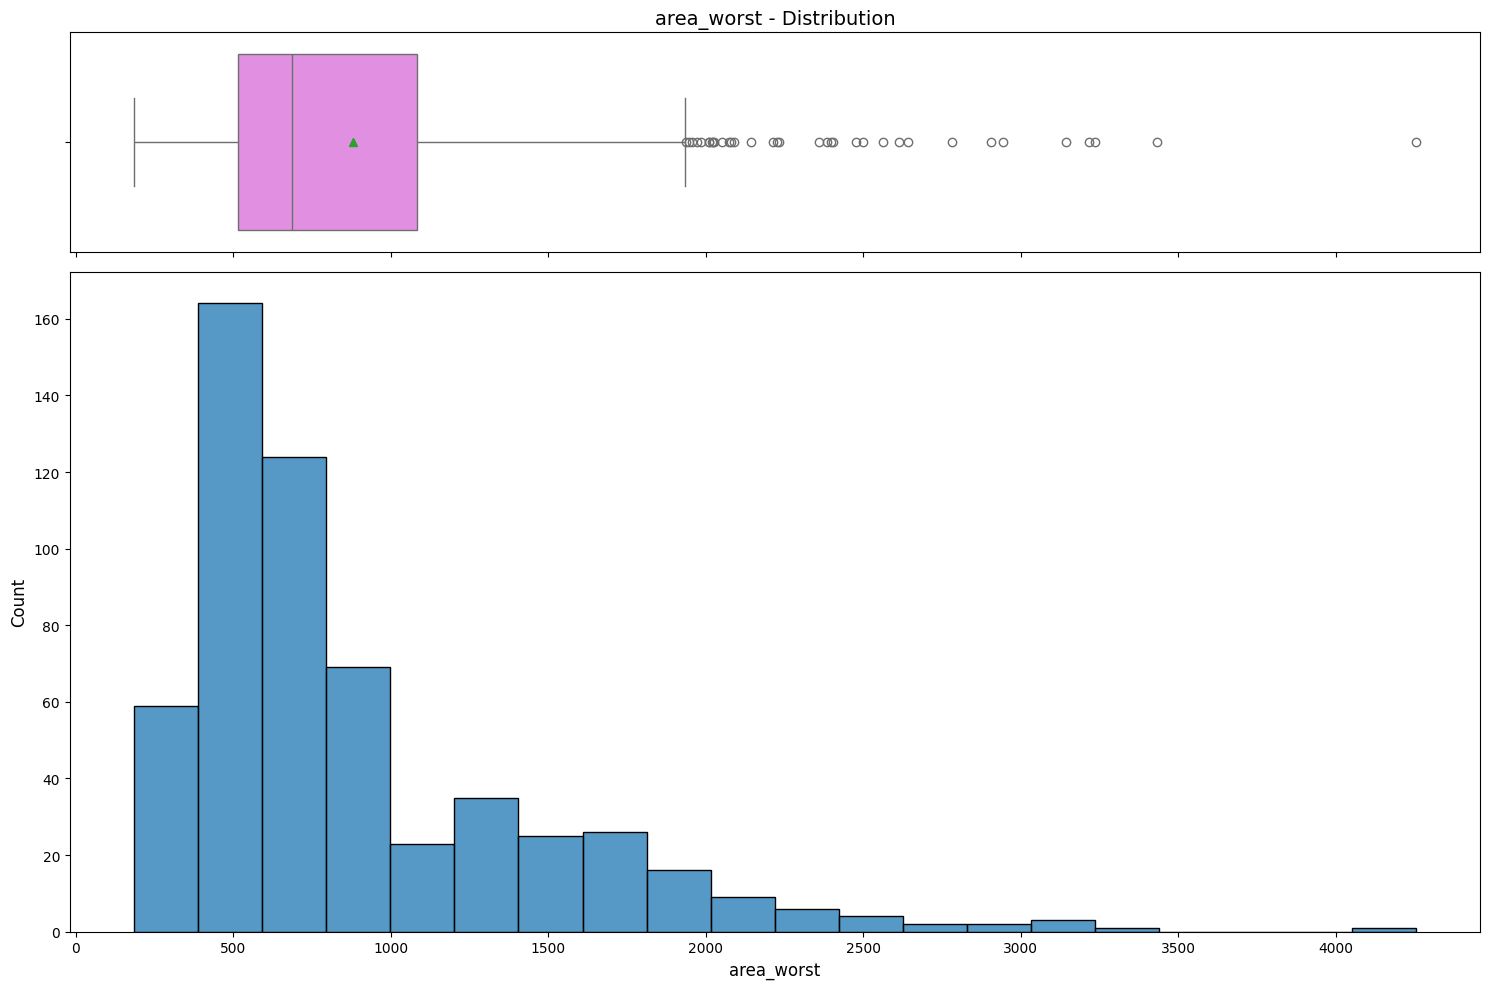

In [ ]:
histogram_boxplot(df1,"area_worst")

## Observation on smoothness_worst

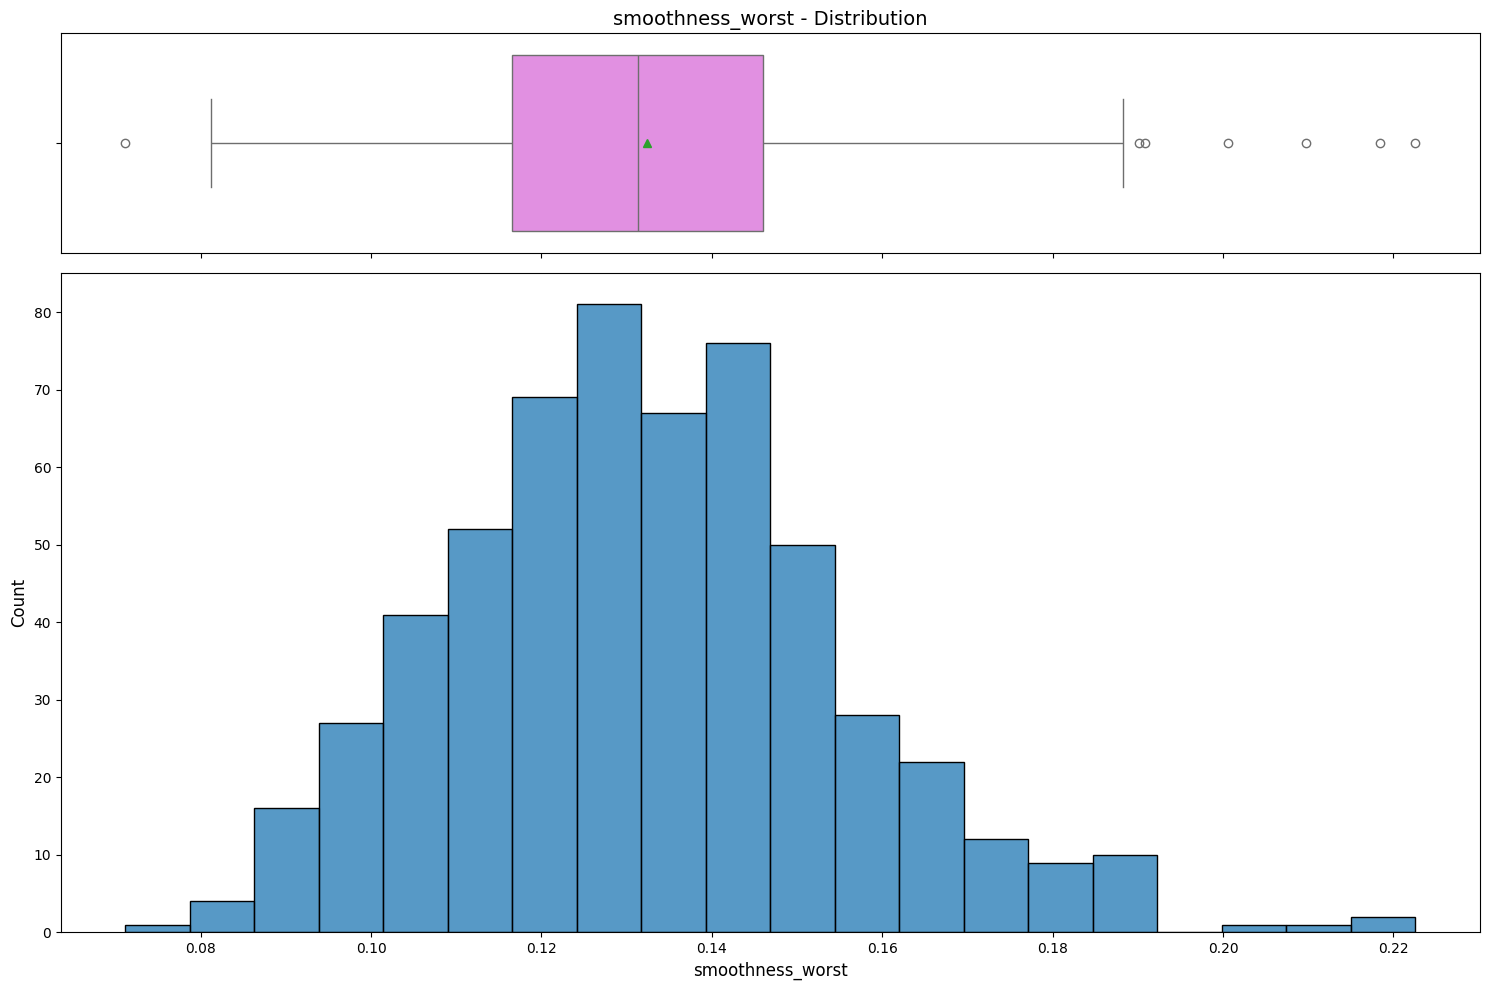

In [ ]:
histogram_boxplot(df1,"smoothness_worst")

## Observation on compactness_worst

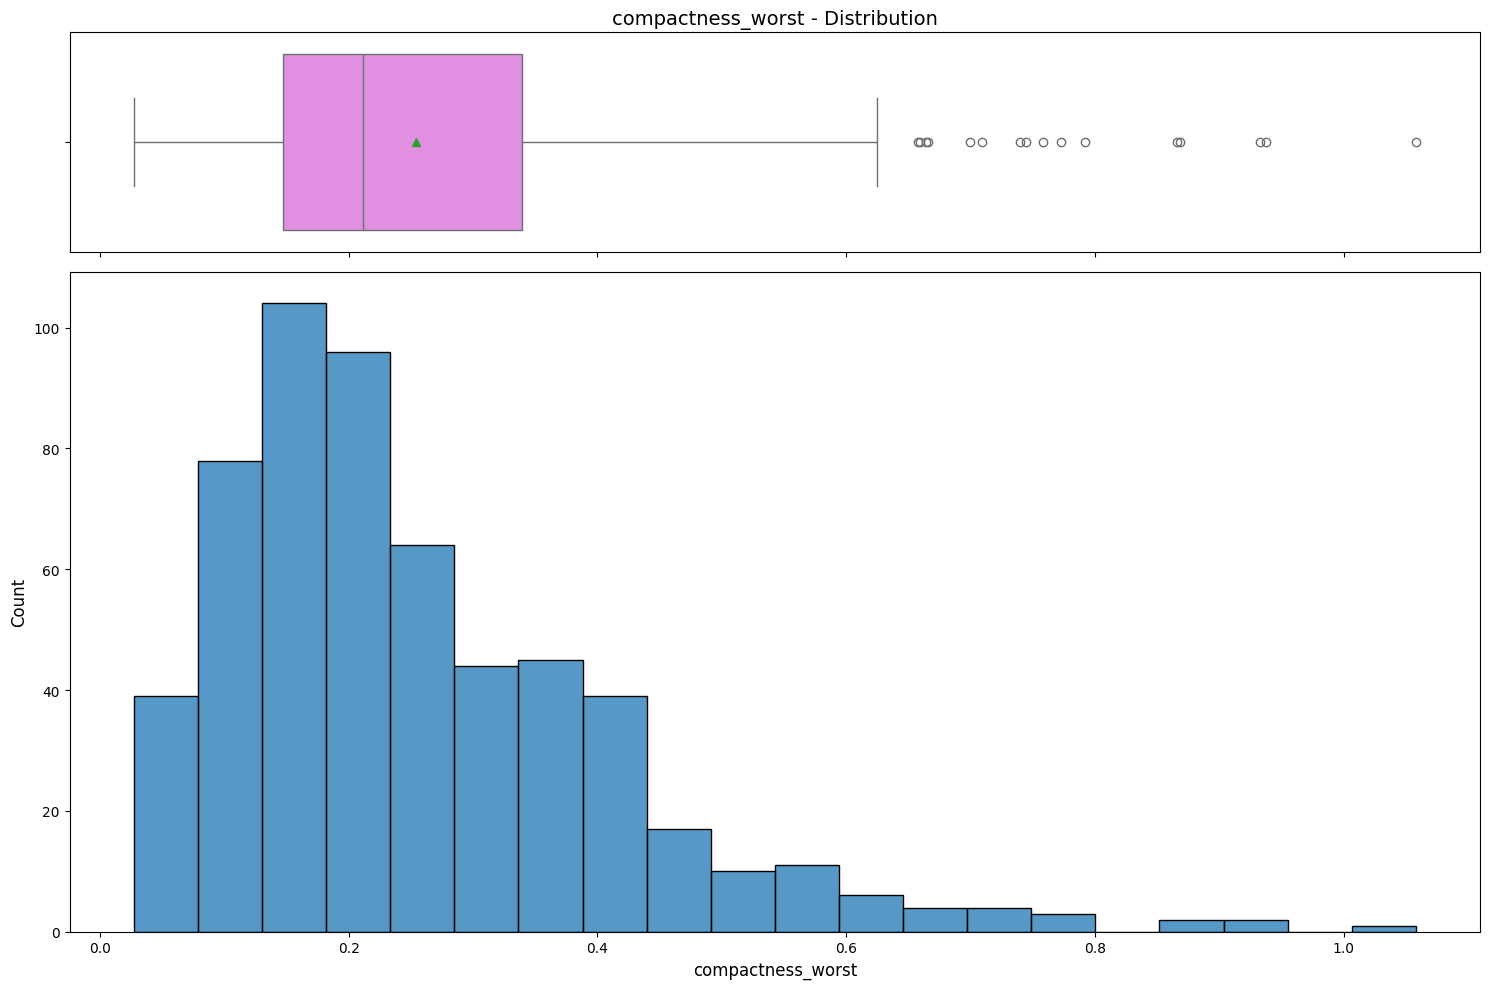

In [ ]:
histogram_boxplot(df1,"compactness_worst")

## Observation on concavity_worst

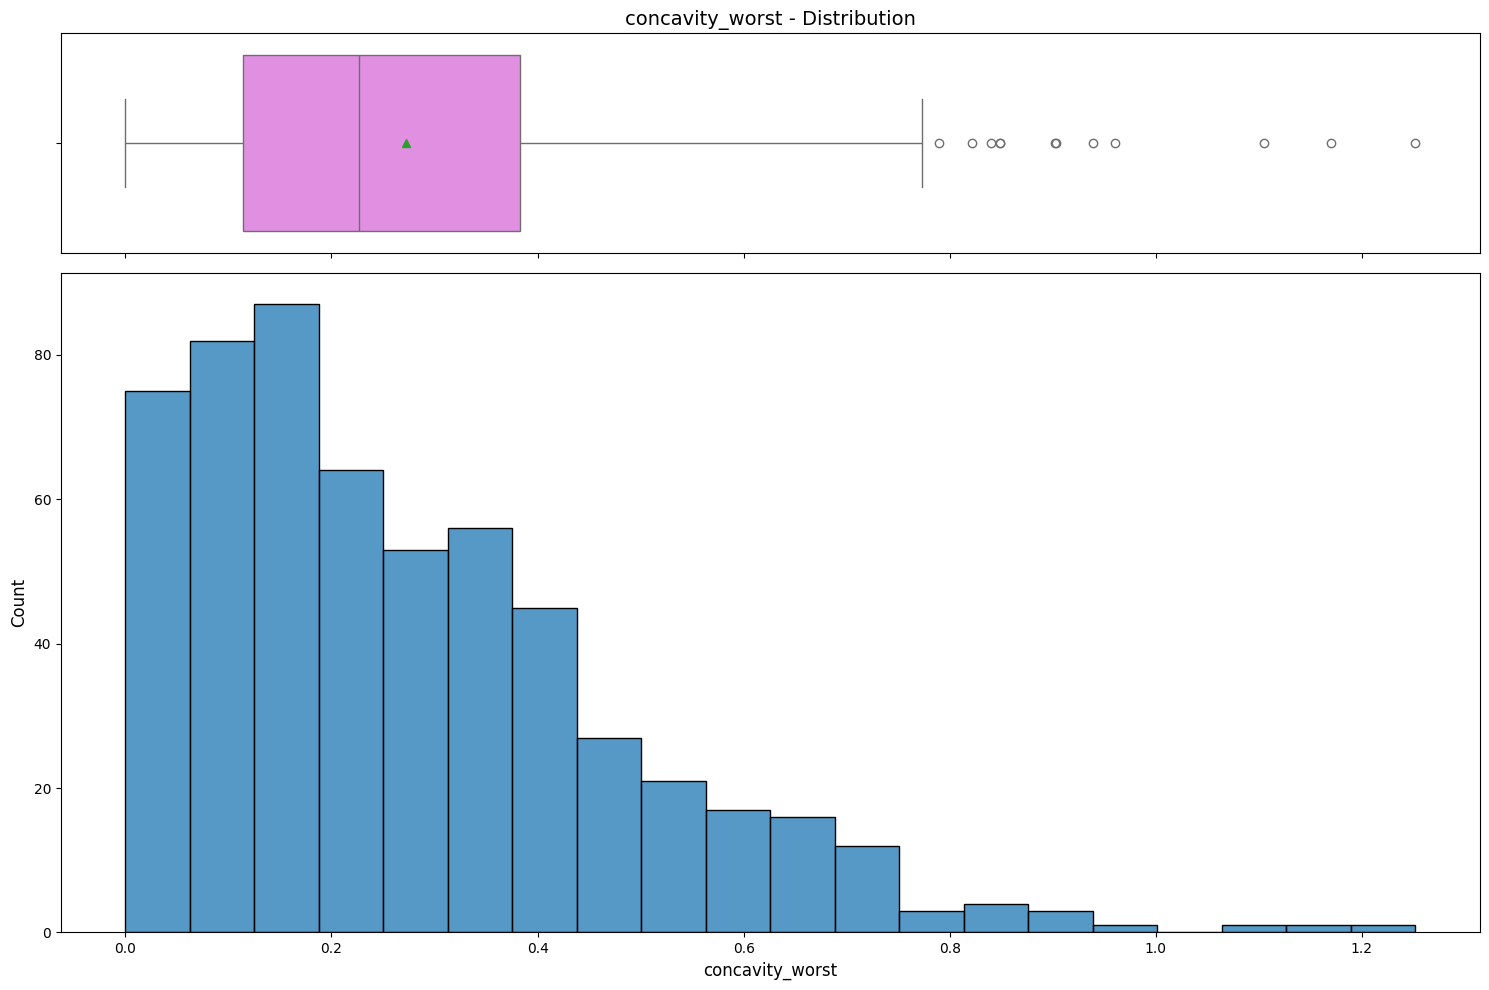

In [ ]:
histogram_boxplot(df1,"concavity_worst")

## Observation on concave points_worst

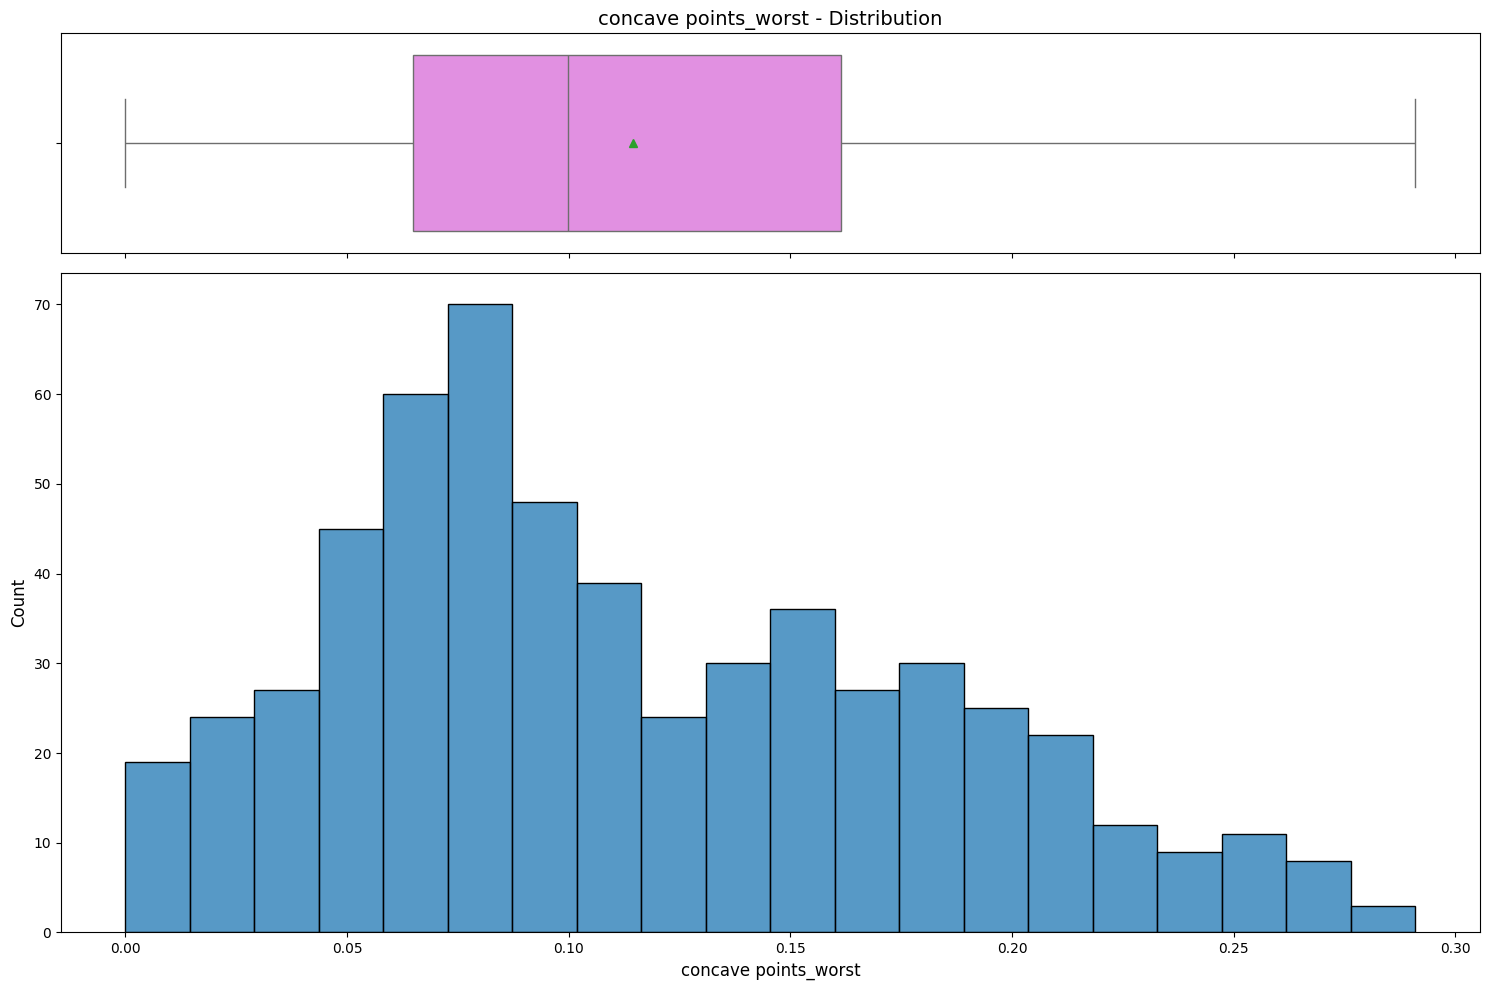

In [ ]:
histogram_boxplot(df1,"concave points_worst")

## Observation on symmetry_worst

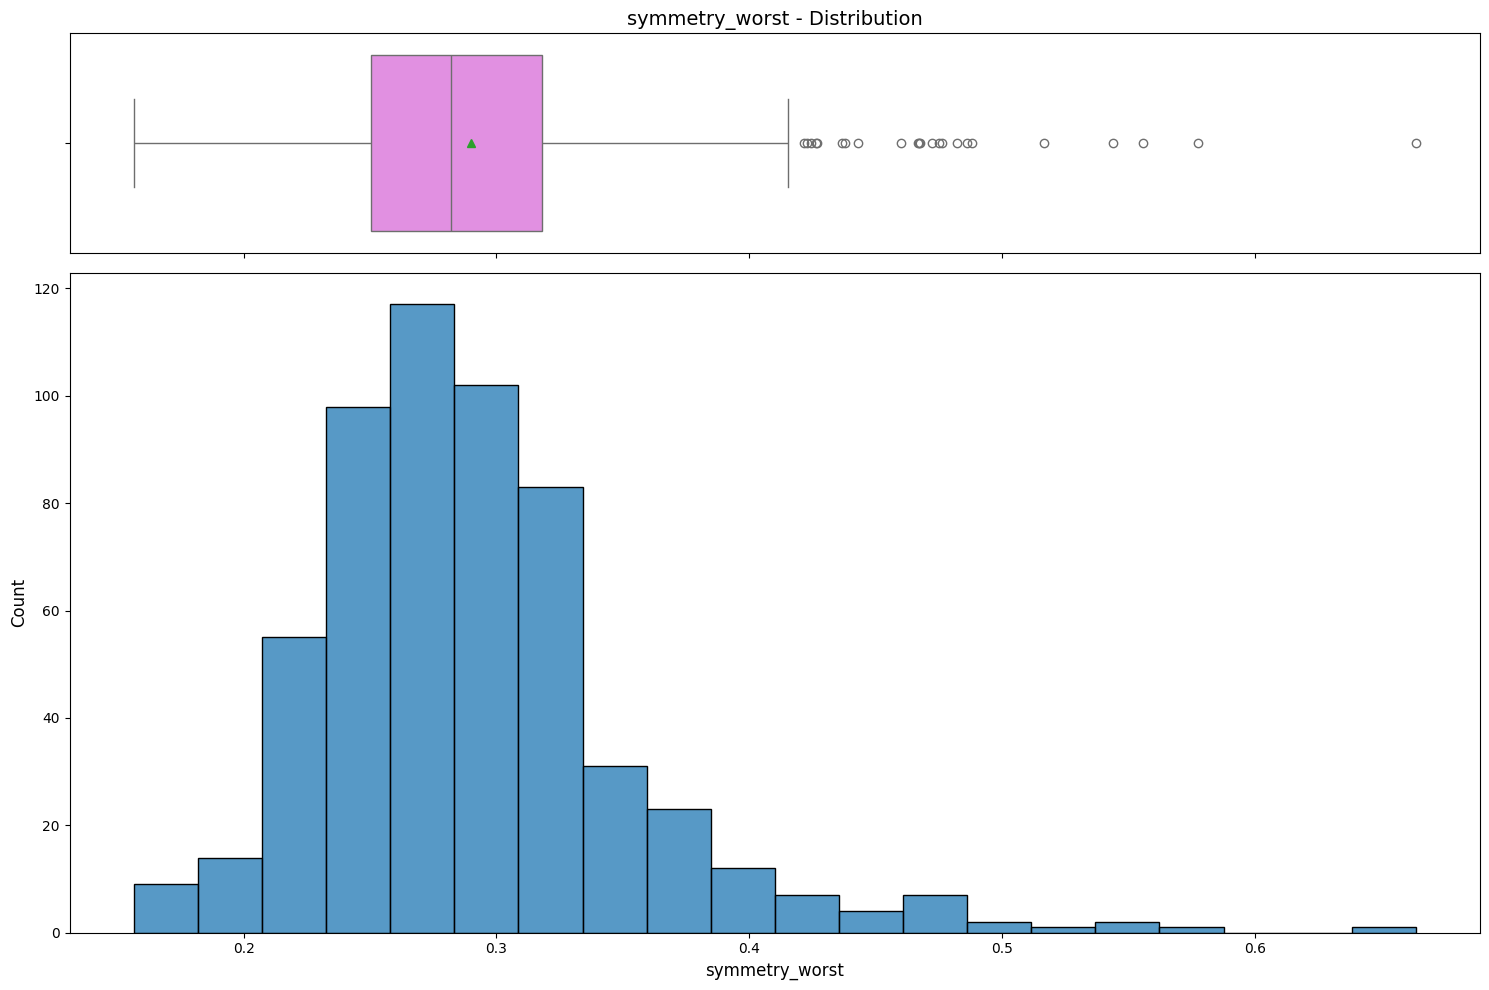

In [ ]:
histogram_boxplot(df1,"symmetry_worst")

## Observation on fractal_dimension_worst

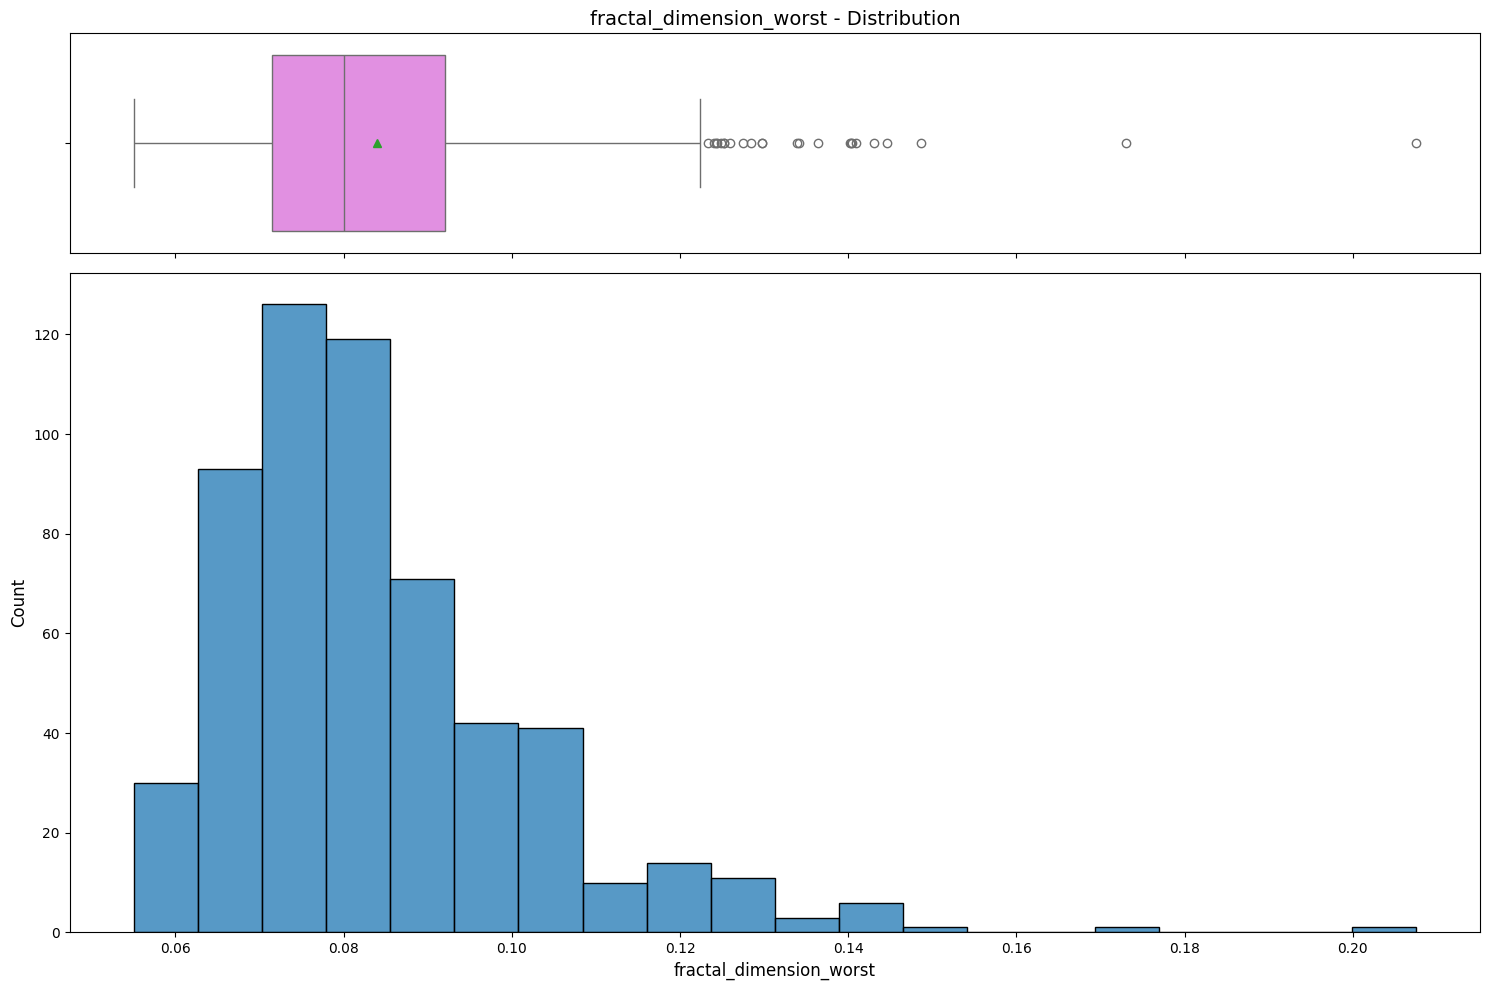

In [ ]:
histogram_boxplot(df1,"fractal_dimension_worst")

# Univariate analysis

# Observation on diagnosis

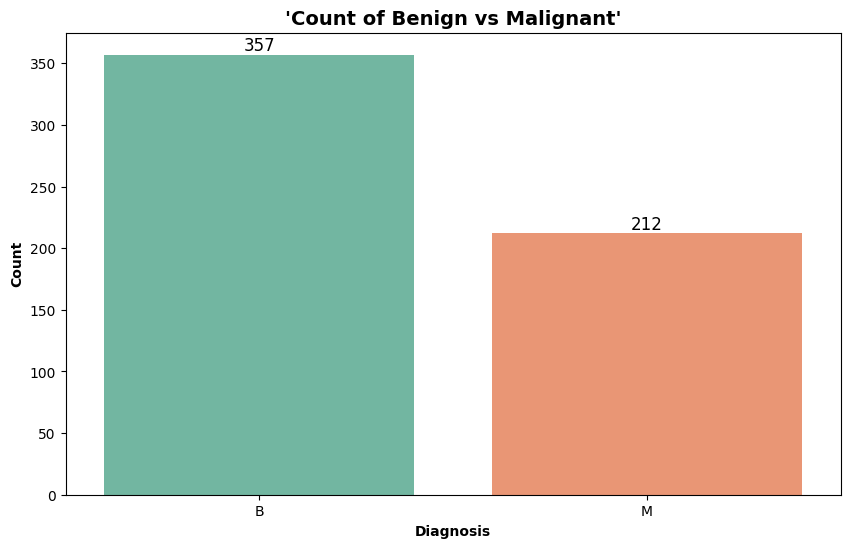

In [38]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df1,x="diagnosis",palette = "Set2")
for container in ax.containers:
        ax.bar_label(container, fontsize=12)
plt.title("'Count of Benign vs Malignant'",fontsize=14,fontweight="bold")
plt.xlabel("Diagnosis",weight="bold")
plt.ylabel("Count",weight="bold")
plt.show()

# Bivariate Analysis

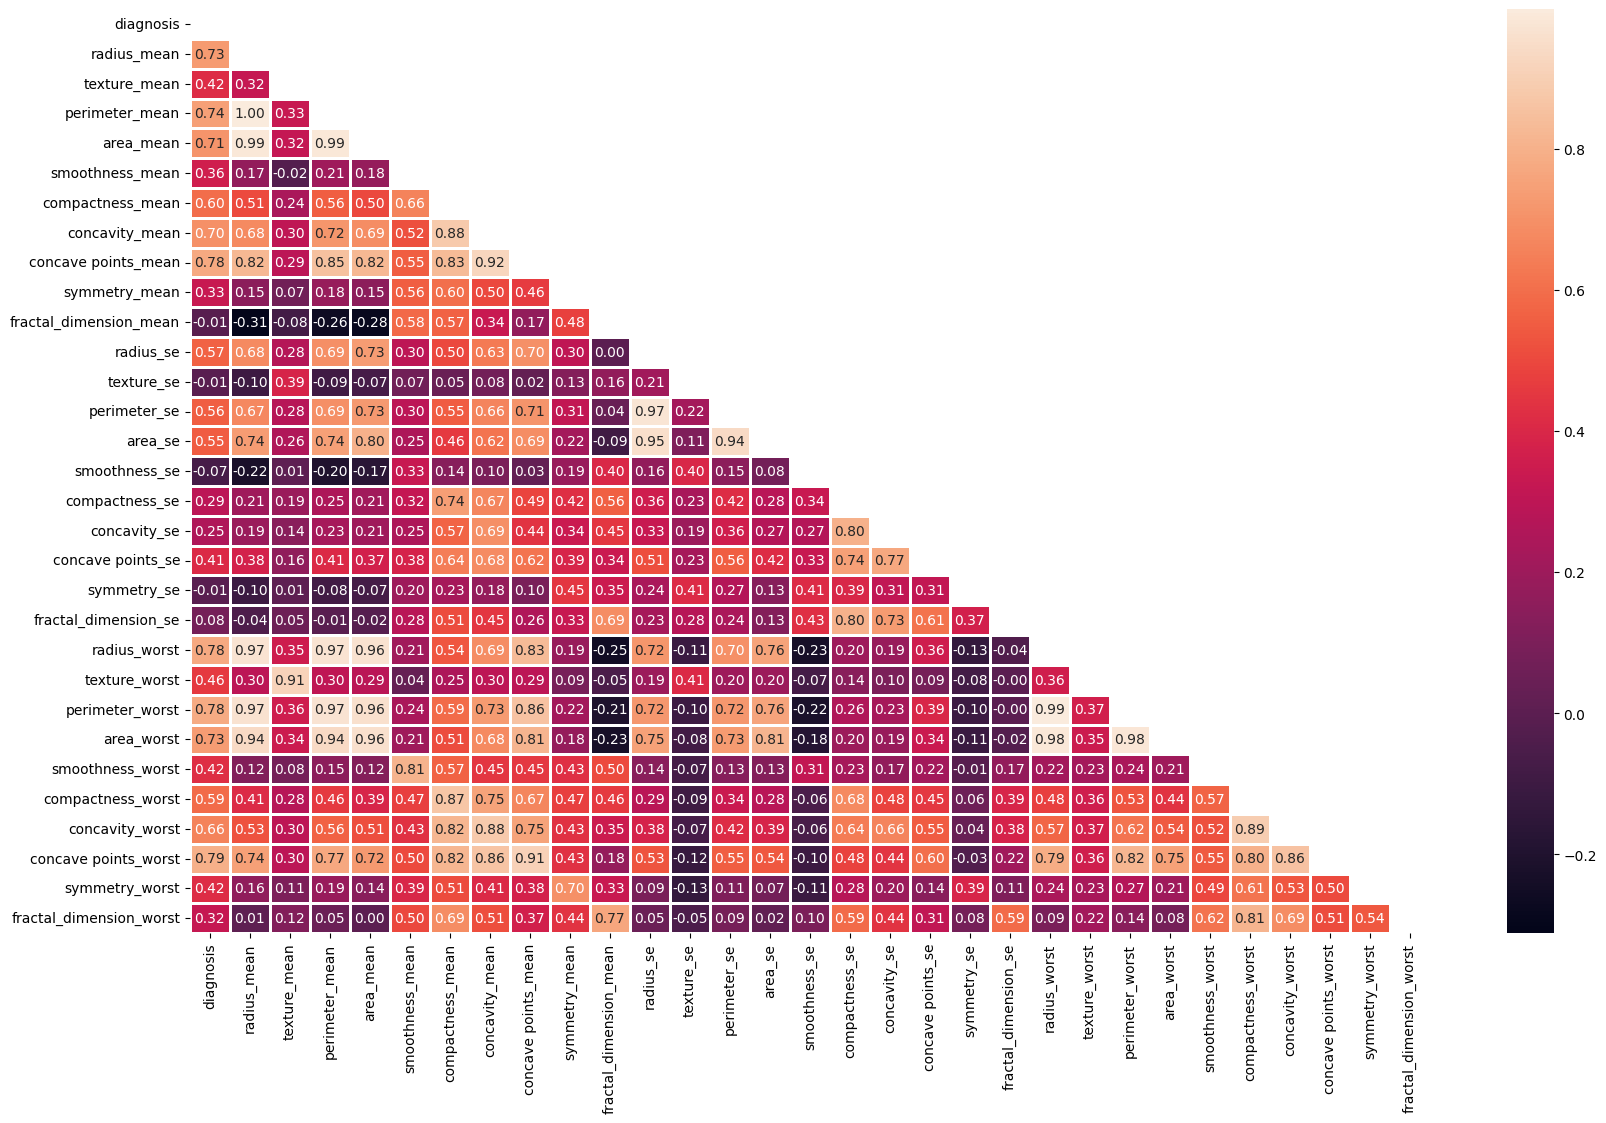

In [ ]:
plt.figure(figsize=(20,12))
df1['diagnosis'] = df1['diagnosis'].map({'M': 1, 'B': 0}).astype(int) # Ensure 'diagnosis' is numeric
corr= df1.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,linewidths=True ,annot=True, fmt=".2f")
plt.show()

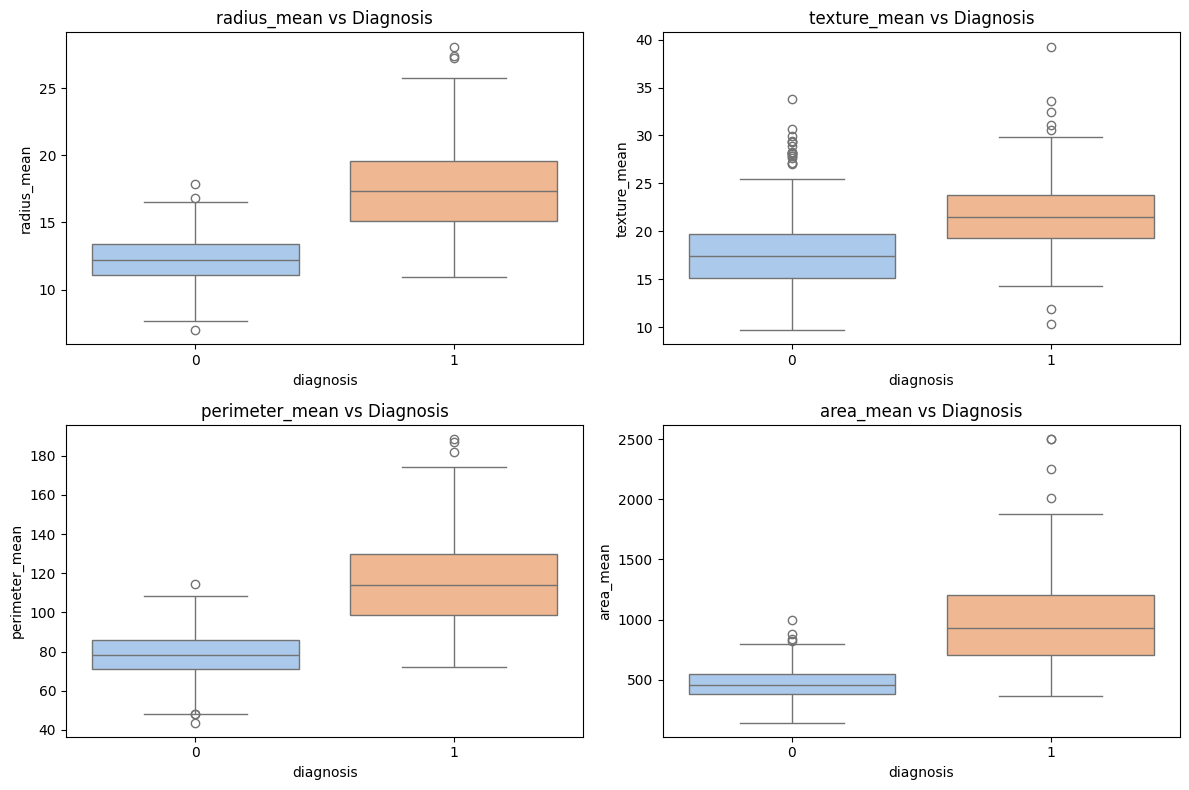

In [ ]:
# Kuch main features ka Box Plot diagnosis ke saath
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feature, data=df1, palette='pastel')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

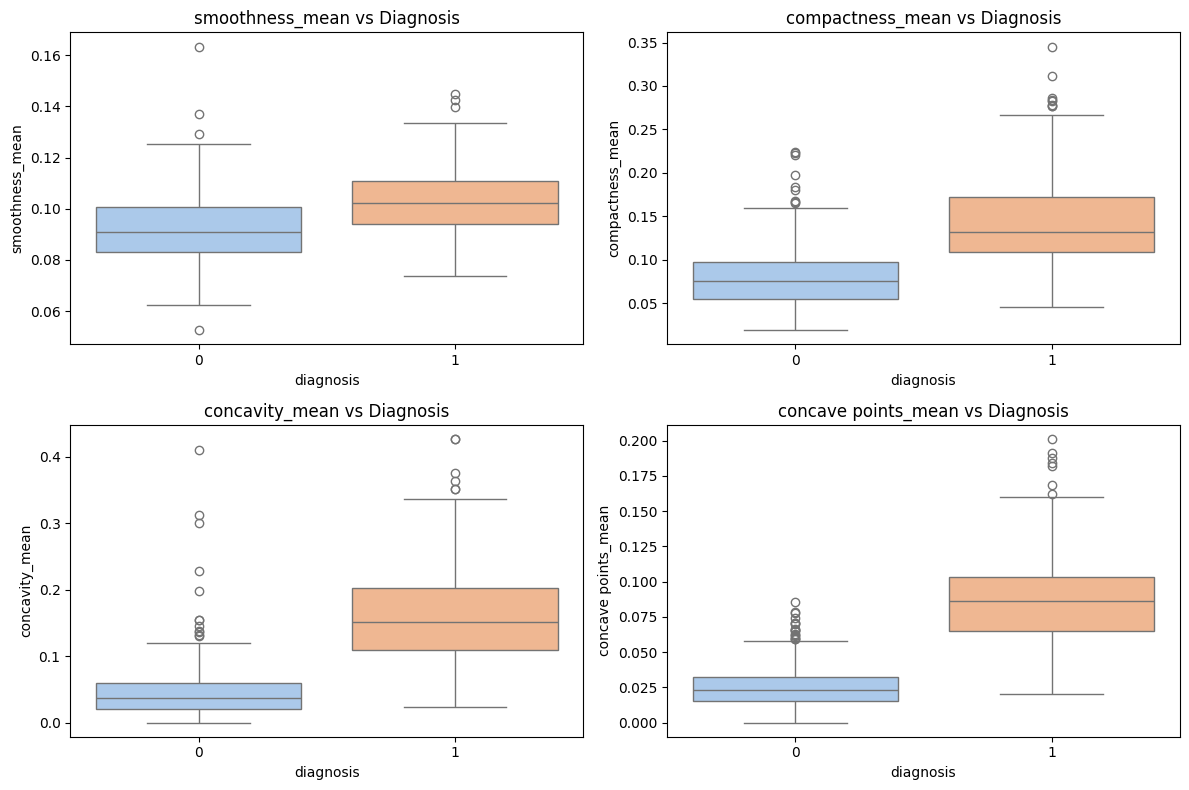

In [ ]:
# Kuch main features ka Box Plot diagnosis ke saath
features_to_plot = ['smoothness_mean', 'compactness_mean', 'concavity_mean','concave points_mean']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feature, data=df1, palette='pastel')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

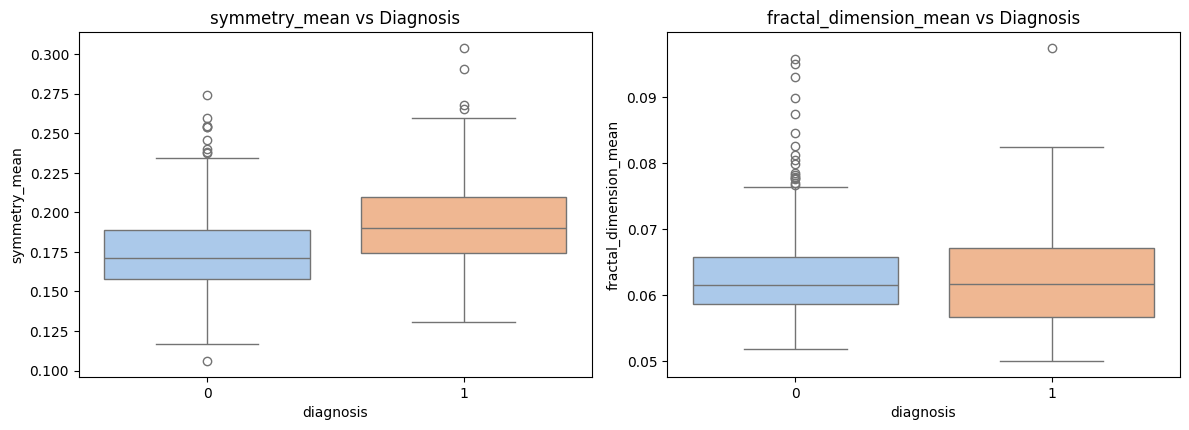

In [ ]:
features_to_plot = ['symmetry_mean', 'fractal_dimension_mean']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feature, data=df1, palette='pastel')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

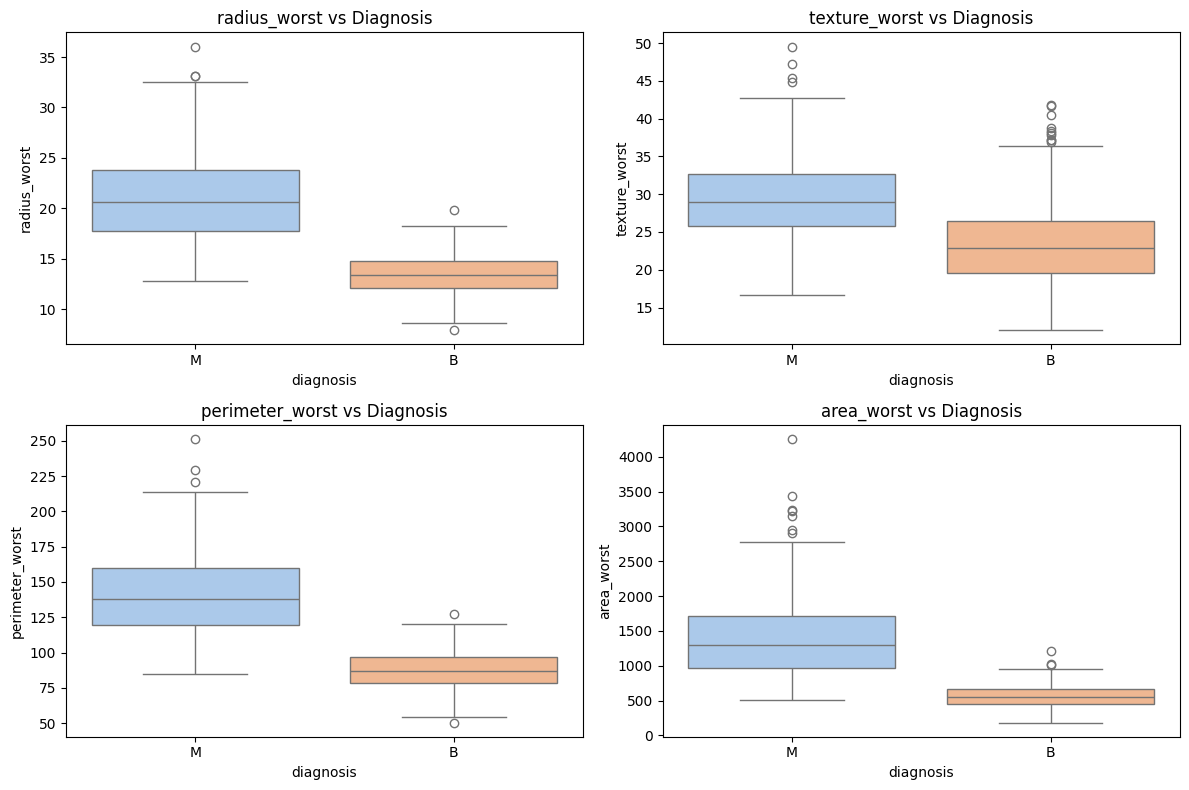

In [ ]:
features_to_plot = ['radius_worst', 'texture_worst','perimeter_worst', 'area_worst']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

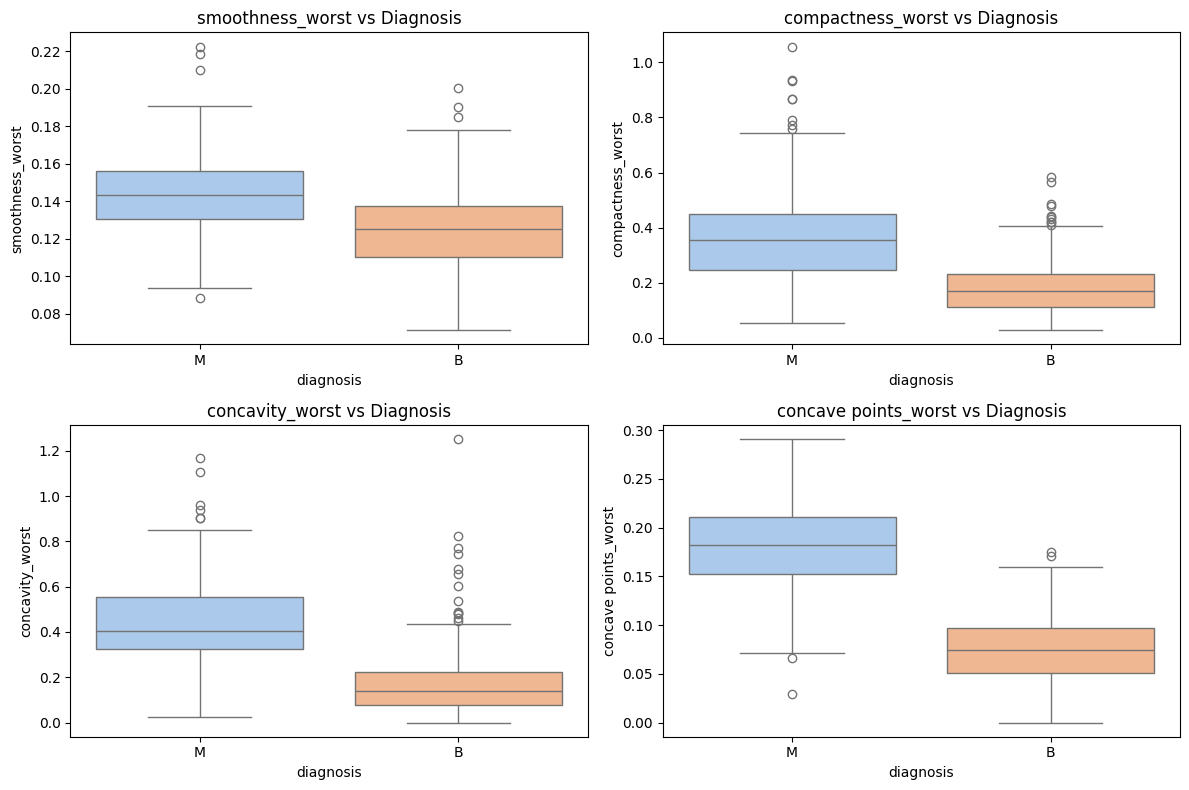

In [ ]:
features_to_plot = ['smoothness_worst','compactness_worst', 'concavity_worst', 'concave points_worst']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

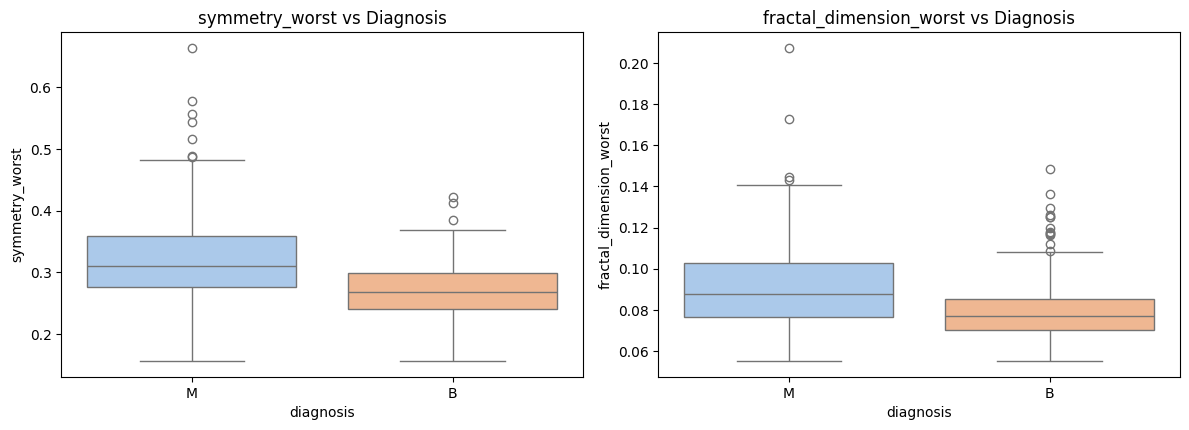

In [ ]:
features_to_plot = ['symmetry_worst', 'fractal_dimension_worst']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

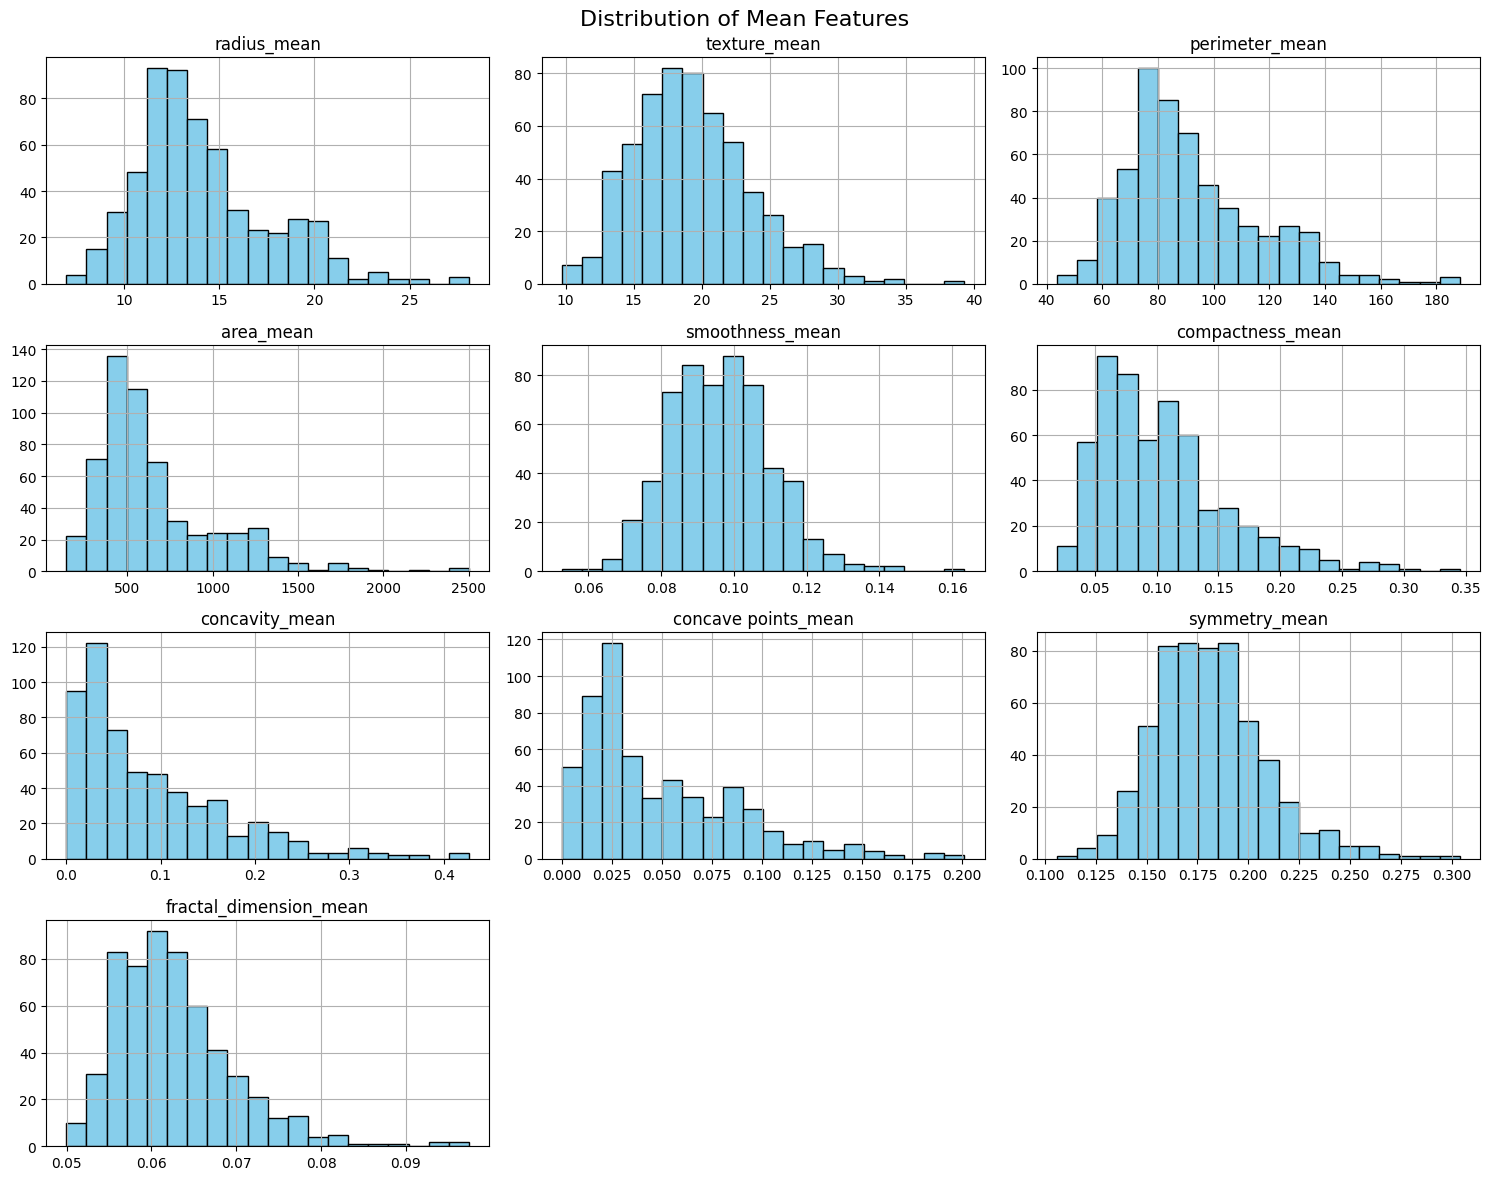

In [ ]:
# Sirf _mean waale columns select karna
mean_features = [col for col in df.columns if '_mean' in col]

# Histograms plot karna
df[mean_features].hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Mean Features', fontsize=16)
plt.tight_layout()
plt.show()

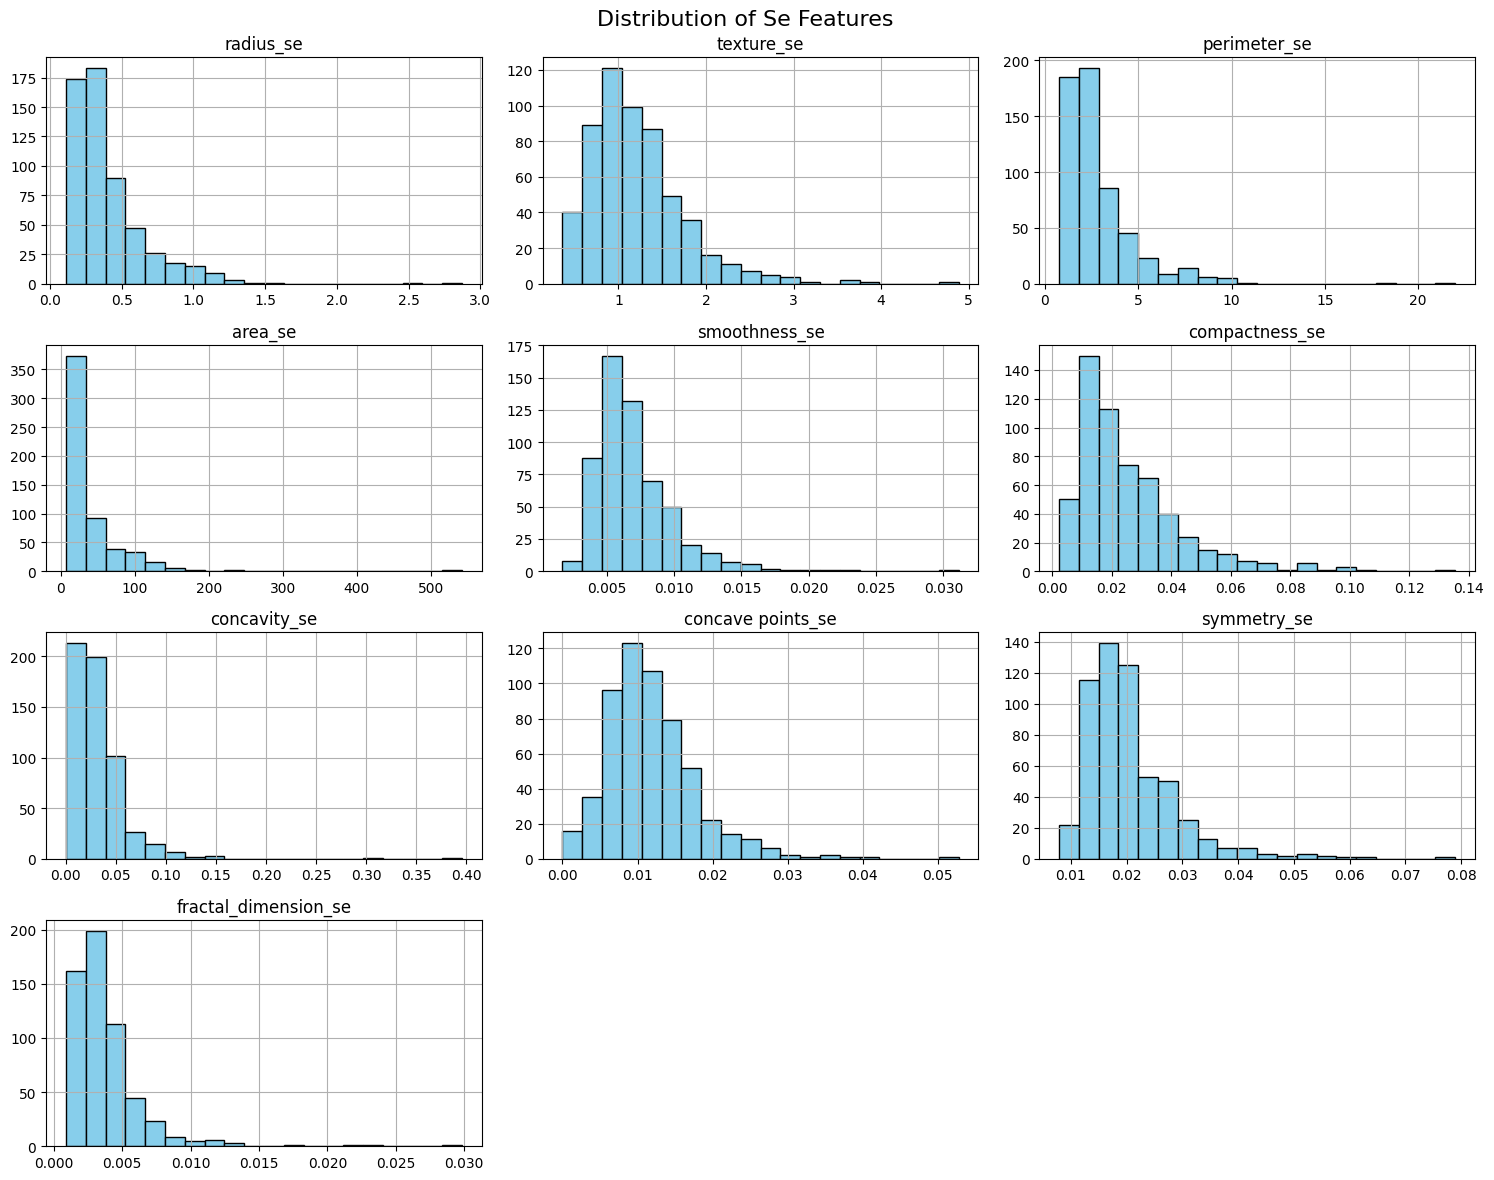

In [ ]:
# Sirf _mean waale columns select karna
se_features = [col for col in df.columns if '_se' in col]

# Histograms plot karna
df[se_features].hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Se Features', fontsize=16)
plt.tight_layout()
plt.show()

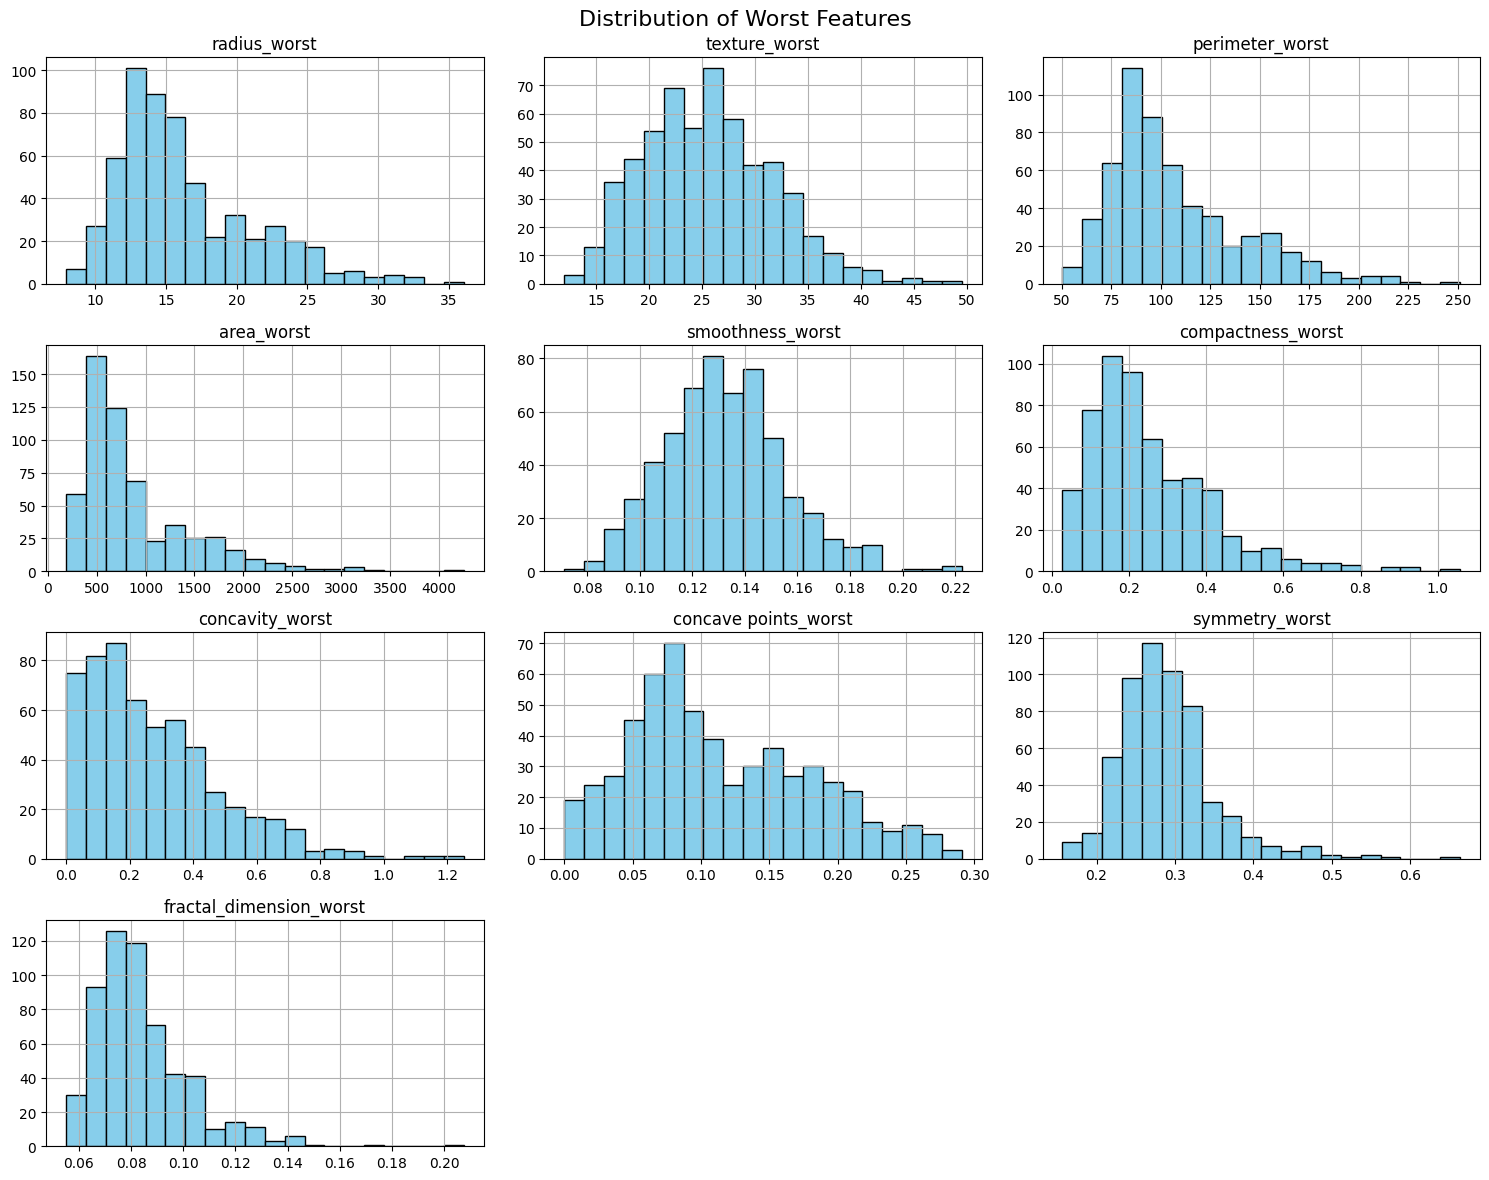

In [ ]:
# Sirf _mean waale columns select karna
worst_features = [col for col in df.columns if '_worst' in col]

# Histograms plot karna
df[worst_features].hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Worst Features', fontsize=16)
plt.tight_layout()
plt.show()

In [93]:
# ==========================================
#  SEPARATE FEATURES (X) AND TARGET (y)
# ==========================================
# 'diagnosis' target hai, baaki sabhi 30 columns features hain
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [146]:
print("==========================================")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("==========================================")

Training set size: 455 samples
Testing set size: 114 samples


## Standard scaler

In [95]:
# ==========================================
# STEP 4: FEATURE SCALING (Standardization)
# ==========================================
# 'area', 'radius' aur 'smoothness' ka scale barabar karne ke liye
scaler = StandardScaler()

# Train data ko fit aur transform dono karenge
X_train_scaled = scaler.fit_transform(X_train)

# Test data ko sirf transform karenge (data leakage se bachne ke liye)
X_test_scaled = scaler.transform(X_test)

# Build kNN Model

In [110]:
KNN = KNeighborsClassifier(n_neighbors= 5 , weights = 'distance' )

In [111]:
KNN.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

In [112]:
predicted_labels = KNN.predict(X_test)
KNN.score(X_test, y_test)

0.7894736842105263

In [113]:
# 3. Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[70  1]
 [ 2 41]]


In [114]:
# ==========================================
# STEP 5: MODEL TRAINING (Logistic Regression)
# ==========================================
# Model initialize kiya
model = LogisticRegression(max_iter=1000)

# Scaled training data par model ko train kiya
model.fit(X_train_scaled, y_train)
print("\n--- Model Training Completed Successfully ---")


--- Model Training Completed Successfully ---


In [116]:
# ==========================================
# PREDICTION & EVALUATION
# ==========================================
# Test data par predictions nikalte hain
y_pred = model.predict(X_test_scaled)

## Accuracy

In [117]:
# 1. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("\n==========================================")
print(f"  FINAL MODEL ACCURACY: {accuracy * 100:.2f}%")
print("==========================================")


  FINAL MODEL ACCURACY: 97.37%


In [142]:
# 2. Detailed Classification Report (Precision, Recall, F1-Score)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Detailed Classification Report:
              precision    recall  f1-score   support

           B       0.65      0.39      0.49        71
           M       0.39      0.65      0.49        43

    accuracy                           0.49       114
   macro avg       0.52      0.52      0.49       114
weighted avg       0.55      0.49      0.49       114



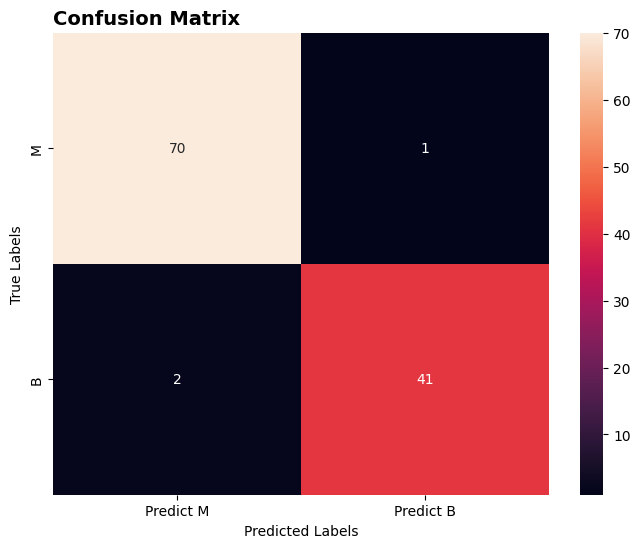

In [123]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=['Predict M', 'Predict B'],
            yticklabels=['M', 'B'])

plt.title('Confusion Matrix', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()

In [149]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

KNeighborsClassifier()

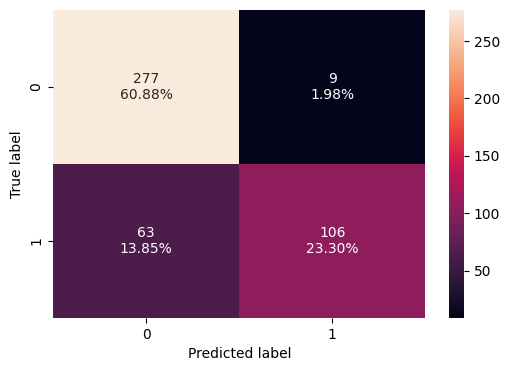

In [151]:
y_train_numeric = y_train.map({'M': 1, 'B': 0})
confusion_matrix_sklearn(model, X_train, y_train_numeric)

In [154]:
def model_performance_classification_sklearn(model, X, y_true):

    # Ensure y_true is numeric if it's categorical (M/B)
    if y_true.dtype == 'object':
        y_true_numeric = y_true.map({'M': 1, 'B': 0})
    else:
        y_true_numeric = y_true

    y_pred = model.predict(X)

    # Ensure y_pred is numeric if it's categorical (M/B), to match y_true_numeric
    if pd.Series(y_pred).dtype == 'object':
        y_pred_numeric = pd.Series(y_pred).map({'M': 1, 'B': 0})
    else:
        y_pred_numeric = pd.Series(y_pred)

    print(f"Accuracy: {accuracy_score(y_true_numeric, y_pred_numeric):.4f}")
    print("\nClassification Report:\n", classification_report(y_true_numeric, y_pred_numeric))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true_numeric, y_pred_numeric))

log_reg_model_train_perf=model_performance_classification_sklearn(
    model,X_train,y_train)
print("Training performance:")

Accuracy: 0.8418

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88       286
           1       0.92      0.63      0.75       169

    accuracy                           0.84       455
   macro avg       0.87      0.80      0.82       455
weighted avg       0.85      0.84      0.83       455


Confusion Matrix:
 [[277   9]
 [ 63 106]]
Training performance:


In [156]:
print("Test performance:")
model_performance_classification_sklearn(model, X_test, y_test)

Test performance:
Accuracy: 0.7544

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.89      0.82        71
           1       0.74      0.53      0.62        43

    accuracy                           0.75       114
   macro avg       0.75      0.71      0.72       114
weighted avg       0.75      0.75      0.74       114


Confusion Matrix:
 [[63  8]
 [20 23]]


In [157]:
# Checking model performance for this model

log_reg_model_test_perf=model_performance_classification_sklearn(
    model,X_test,y_test
)

print("Test Performance")
log_reg_model_test_perf

Accuracy: 0.7544

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.89      0.82        71
           1       0.74      0.53      0.62        43

    accuracy                           0.75       114
   macro avg       0.75      0.71      0.72       114
weighted avg       0.75      0.75      0.74       114


Confusion Matrix:
 [[63  8]
 [20 23]]
Test Performance
